In [1]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
LOG_DIR = Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/1p3d_Qwen-0.6B_real-workload/no_disagg')

def parse_core_log_cached(filepath):
    records = []
    with open(filepath) as f:
        for line in f:
            try:
                e = json.loads(line)
            except json.JSONDecodeError:
                continue
            if e.get('event') != 'step_end':
                continue
            for rid, ctokens in zip(e.get('finished_request_ids', []), e.get('num_cached_tokens', [])):
                parts = rid.split('-')  # cmpl-{conv_id}-{iter_id}-0
                if len(parts) == 4:
                    records.append({
                        'request_id': rid,
                        'conv_id':     int(parts[1]),
                        'iter_id':     int(parts[2]),
                        'cached_tokens': ctokens,
                    })
    return records

# Collect from all engine core logs (prefiller + decoder1/2/3)
core_logs = sorted(LOG_DIR.glob('*_core_log.jsonl'))
all_records = []
for log in core_logs:
    engine_name = log.name.replace('_vllm_core_log.jsonl', '')
    for r in parse_core_log_cached(log):
        r['engine'] = engine_name
        all_records.append(r)

cache_df = pd.DataFrame(all_records).sort_values(['conv_id', 'iter_id']).reset_index(drop=True)

# profile_agent.py routes conv_id % 4 (3 decoders + 1 prefiller = engine_count=4)
ENGINE_COUNT = 4
cache_df['engine_id'] = cache_df['conv_id'] % ENGINE_COUNT

# Rank 0 = first conversation to arrive on that engine
cache_df['conv_rank'] = cache_df.groupby('engine_id')['conv_id'].transform(
    lambda x: pd.factorize(x.sort_values())[0][x.argsort().argsort()]
)

# iter_id >= 1 should benefit from prefix caching (full prompt starts with prompt[0])
rest = cache_df[cache_df['iter_id'] >= 1].copy()
rest['hit'] = rest['cached_tokens'] > 0

hit_by_rank = (
    rest.groupby('conv_rank')['hit']
    .agg(hit_rate='mean', n_requests='count')
    .reset_index()
)

print(f'Core logs parsed: {[l.name for l in core_logs]}')
print(f'Total iter_id>=1 requests: {len(rest)}')
print(f'Overall cache hit rate:    {rest["hit"].mean():.1%}')
print()
hit_by_rank.head(30)


Core logs parsed: ['decoder1_vllm_core_log.jsonl', 'decoder2_vllm_core_log.jsonl', 'decoder3_vllm_core_log.jsonl', 'prefiller_vllm_core_log.jsonl']
Total iter_id>=1 requests: 467135
Overall cache hit rate:    25.5%



,conv_rank,hit_rate,n_requests
0,0,0.770280,9677
1,1,0.866982,13750
2,2,1.000000,8969
3,3,0.909990,6777
4,4,0.830240,9914
5,5,0.832034,8591
6,6,0.960068,5885
7,7,0.834489,10386
8,8,0.758998,9502
9,9,0.707076,14485


In [3]:
# 2D view: rows = conv_id, columns = iter_id (1..N), values = cached_tokens (0 = miss)
pivot = (
    cache_df[cache_df['iter_id'] >= 1]
    .pivot_table(index='conv_id', columns='iter_id', values='cached_tokens', aggfunc='first')
    .sort_index()
)
pivot.columns.name = 'iter_id'
pivot.index.name   = 'conv_id'
pivot


iter_id,1,2,3,4,5,6,7,8,9
conv_id,,,,,,,,,
0,17920.0,18128.0,18240.0,18368.0,18480.0,18608.0,18720.0,19072.0,19312.0
1,14320.0,14480.0,14592.0,14720.0,14864.0,15072.0,0.0,0.0,0.0
2,12416.0,12688.0,12816.0,12928.0,13040.0,13168.0,13344.0,13632.0,14256.0
3,14320.0,14480.0,14592.0,14704.0,14880.0,15168.0,15392.0,15712.0,16352.0
4,16416.0,16624.0,16736.0,16848.0,16976.0,17424.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
581,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
583,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
585,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# adaptive_disagg_rest: prefix cache hit analysis for iter_id >= 1
# Routing: conv_id % 3 (decoder_count=3, no prefiller)
# iter_id=0 are dummy warm-up prefills (run_conversation_first, 1 token) — excluded

ADR_LOG_DIR = Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/1p3d_Qwen-0.6B_real-workload/adaptive_disagg_rest')

adr_logs = sorted(ADR_LOG_DIR.glob('*_core_log.jsonl'))
adr_records = []
for log in adr_logs:
    engine_name = log.name.replace('_vllm_core_log.jsonl', '')
    for r in parse_core_log_cached(log):
        r['engine'] = engine_name
        adr_records.append(r)

adr_df = pd.DataFrame(adr_records).sort_values(['conv_id', 'iter_id']).reset_index(drop=True)

# adaptive_disagg_rest: decoder_count=3, conv_id % 3
ADR_ENGINE_COUNT = 3
adr_df['engine_id'] = adr_df['conv_id'] % ADR_ENGINE_COUNT
adr_df['conv_rank'] = adr_df.groupby('engine_id')['conv_id'].transform(
    lambda x: pd.factorize(x.sort_values())[0][x.argsort().argsort()]
)

# Exclude iter_id=0 dummy warm-up calls; only real rest iterations
adr_rest = adr_df[adr_df['iter_id'] >= 1].copy()
adr_rest['hit'] = adr_rest['cached_tokens'] > 0

adr_hit_by_rank = (
    adr_rest.groupby('conv_rank')['hit']
    .agg(hit_rate='mean', n_requests='count')
    .reset_index()
)

print(f"Core logs parsed: {[l.name for l in adr_logs]}")
print(f"Total iter_id>=1 requests: {len(adr_rest)}")
print(f"Overall cache hit rate:    {adr_rest['hit'].mean():.1%}")
print()

# 2D pivot: rows = conv_id, columns = iter_id (1..N), values = cached_tokens
adr_pivot = (
    adr_rest
    .pivot_table(index='conv_id', columns='iter_id', values='cached_tokens', aggfunc='first')
    .sort_index()
)
adr_pivot.columns.name = 'iter_id'
adr_pivot.index.name   = 'conv_id'
adr_pivot


Core logs parsed: ['decoder1_vllm_core_log.jsonl', 'decoder2_vllm_core_log.jsonl', 'decoder3_vllm_core_log.jsonl']
Total iter_id>=1 requests: 295347
Overall cache hit rate:    19.4%



iter_id,1,2,3,4,5,6,7,8,9
conv_id,,,,,,,,,
0,17920.0,18128.0,18240.0,18368.0,18480.0,18608.0,18720.0,19072.0,19296.0
1,14320.0,14480.0,14592.0,14720.0,14864.0,15072.0,0.0,0.0,0.0
2,12416.0,12688.0,12816.0,12928.0,13040.0,13168.0,13344.0,13632.0,0.0
3,14320.0,14480.0,14592.0,14704.0,14896.0,15168.0,15392.0,0.0,0.0
4,16416.0,16624.0,16736.0,16848.0,16976.0,17424.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
504,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
505,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# --- What the data actually means ---
# num_cached_tokens in step_end fires on EVERY DECODE STEP (one token produced),
# not once per request completion. So each (conv_id, iter_id) appears once per
# output token generated. The cached_tokens value is constant across all decode
# steps of the same request (set at scheduling time).
#
# For conv_id=0:
#   iter_id=0 warm-up  (max_tokens=1)  → 1 row,  cached_tokens=0
#   iter_id=0 rest phase (full output) → N rows, cached_tokens=0  (warm-up KV evicted)
#   iter_id=1 rest phase               → M rows, cached_tokens=17920
#
# Why does iter_id=1 hit? The rest phase calls run_conversation_serial(start_iter_id=0),
# so iter_id=0 runs fresh. When iter_id=0 finishes, its blocks land at the LRU back.
# iter_id=1 starts immediately → full cache hit. Same mechanism as no_disagg.

# Deduplicated view: one row per (conv_id, iter_id)
dedup = (
    adr_df
    .groupby(['conv_id', 'iter_id'])['cached_tokens']
    .first()  # all rows for same (conv_id, iter_id) have identical cached_tokens
    .reset_index()
)

# Show token counts per request (number of output tokens = number of rows per request)
token_counts = adr_df.groupby(['conv_id', 'iter_id']).size().rename('output_tokens').reset_index()

print("conv_id=0: output tokens and cached_tokens per iteration")
summary0 = token_counts[token_counts['conv_id'] == 0].merge(
    dedup[dedup['conv_id'] == 0], on=['conv_id', 'iter_id']
)
print(summary0.to_string(index=False))
print()
print(f"iter_id=0 total rows: {len(adr_df[(adr_df['conv_id']==0) & (adr_df['iter_id']==0)])}")
print(f"  = 1 (warm-up, 1 token) + {len(adr_df[(adr_df['conv_id']==0) & (adr_df['iter_id']==0)])-1} (rest phase output tokens)")


conv_id=0: output tokens and cached_tokens per iteration
 conv_id  iter_id  output_tokens  cached_tokens
       0        0            147              0
       0        1             40          17920
       0        2             58          18128
       0        3             37          18240
       0        4             65          18368
       0        5             47          18480
       0        6            279          18608
       0        7            161          18720
       0        8            355          19072
       0        9            365          19296

iter_id=0 total rows: 147
  = 1 (warm-up, 1 token) + 146 (rest phase output tokens)


In [6]:
LAT_DIR = Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/1p3d_Qwen-0.6B_real-workload/all_disagg')
lat_df = pd.read_csv(LAT_DIR / 'per_step_latency.csv')

t0 = lat_df['start_time'].min()
lat_df['start_rel'] = lat_df['start_time'] - t0
lat_df['end_rel']   = lat_df['end_time']   - t0

# prompt_tokens in the CSV is the new fragment only; accumulate the full prompt
# actually sent to the engine (full conversation history).
# For step k: actual_prompt = sum(prompt_tokens[0..k]) + sum(max_tokens[0..k-1])
def compute_accum(group):
    g = group.sort_values('step_id').copy()
    accum, carry = [], 0
    for _, row in g.iterrows():
        carry += row['prompt_tokens']
        accum.append(carry)
        carry += row['max_tokens']  # previous output becomes next context
    g['accum_prompt'] = accum
    return g

lat_df = lat_df.groupby('conv_id', group_keys=False).apply(compute_accum).sort_values(['conv_id','step_id']).reset_index(drop=True)
lat_df['kv_tokens'] = lat_df['accum_prompt'] + lat_df['max_tokens']

print(f'Rows: {len(lat_df):,}  |  Wall time: {lat_df["end_rel"].max():.0f}s')
print(f'kv_tokens per request - min: {lat_df["kv_tokens"].min()}  '
      f'median: {lat_df["kv_tokens"].median():.0f}  max: {lat_df["kv_tokens"].max()}')
lat_df[['conv_id','step_id','accum_prompt','max_tokens','kv_tokens','latency_sec','start_rel','end_rel']].head(8)


Rows: 2,526  |  Wall time: 1831s
kv_tokens per request - min: 8795.0  median: 16692  max: 36692.0


/data/projects/AgentScaling/tmp/ipykernel_1611101/330646050.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lat_df = lat_df.groupby('conv_id', group_keys=False).apply(compute_accum).sort_values(['conv_id','step_id']).reset_index(drop=True)


,conv_id,step_id,accum_prompt,max_tokens,kv_tokens,latency_sec,start_rel,end_rel
0,0,0,17912.0,146,18058.0,3.0807,0.000000,3.080728
1,0,1,18125.0,40,18165.0,2.5323,3.080924,5.613175
2,0,2,18232.0,58,18290.0,3.4158,5.613347,9.029180
3,0,3,18357.0,37,18394.0,5.2133,9.029324,14.242581
4,0,4,18461.0,65,18526.0,8.8610,14.242726,23.103761
5,0,5,18593.0,47,18640.0,13.7548,23.103989,36.858761
6,0,6,18707.0,279,18986.0,25.6348,36.858972,62.493741
7,0,7,19053.0,161,19214.0,36.7844,62.493977,99.278329


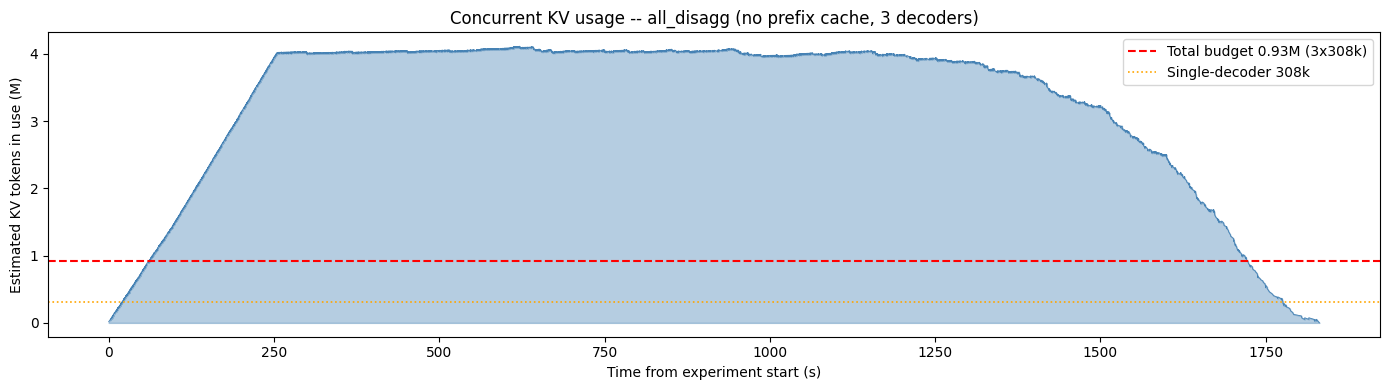

Budget total (925k) exceeded at 4729 event points
Single-decoder budget (308k) exceeded at 4949 event points
Peak KV in use: 4,115,931 tokens (444.8% of total budget)


In [7]:
# Event-based timeline: total KV tokens in use across all decoders at each moment.
# Budget: 3 decoders x 19278 blocks x 16 tokens/block
KV_BUDGET_PER_DECODER = 19_278 * 16   # 308,448
NUM_DECODERS          = 3
KV_BUDGET_TOTAL       = KV_BUDGET_PER_DECODER * NUM_DECODERS  # 925,344

starts_ev = lat_df[['start_rel', 'kv_tokens']].rename(columns={'start_rel': 'time'}).copy()
starts_ev['delta'] = lat_df['kv_tokens']
ends_ev   = lat_df[['end_rel',   'kv_tokens']].rename(columns={'end_rel': 'time'}).copy()
ends_ev['delta'] = -lat_df['kv_tokens']
events = pd.concat([starts_ev, ends_ev]).sort_values('time').reset_index(drop=True)
events['kv_in_use'] = events['delta'].cumsum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(events['time'], events['kv_in_use'] / 1e6, alpha=0.4, color='steelblue')
ax.plot(events['time'], events['kv_in_use'] / 1e6, color='steelblue', linewidth=0.6)
ax.axhline(KV_BUDGET_TOTAL / 1e6, color='red',    linestyle='--', linewidth=1.5,
           label=f'Total budget {KV_BUDGET_TOTAL/1e6:.2f}M ({NUM_DECODERS}x{KV_BUDGET_PER_DECODER//1000}k)')
ax.axhline(KV_BUDGET_PER_DECODER / 1e6, color='orange', linestyle=':', linewidth=1.2,
           label=f'Single-decoder {KV_BUDGET_PER_DECODER//1000}k')
ax.set_xlabel('Time from experiment start (s)')
ax.set_ylabel('Estimated KV tokens in use (M)')
ax.set_title('Concurrent KV usage -- all_disagg (no prefix cache, 3 decoders)')
ax.legend()
plt.tight_layout()
plt.show()

over_total  = (events['kv_in_use'] > KV_BUDGET_TOTAL).sum()
over_single = (events['kv_in_use'] > KV_BUDGET_PER_DECODER).sum()
print(f'Budget total ({KV_BUDGET_TOTAL//1000}k) exceeded at {over_total} event points')
print(f'Single-decoder budget ({KV_BUDGET_PER_DECODER//1000}k) exceeded at {over_single} event points')
print(f'Peak KV in use: {events["kv_in_use"].max():,.0f} tokens '
      f'({events["kv_in_use"].max() / KV_BUDGET_TOTAL:.1%} of total budget)')


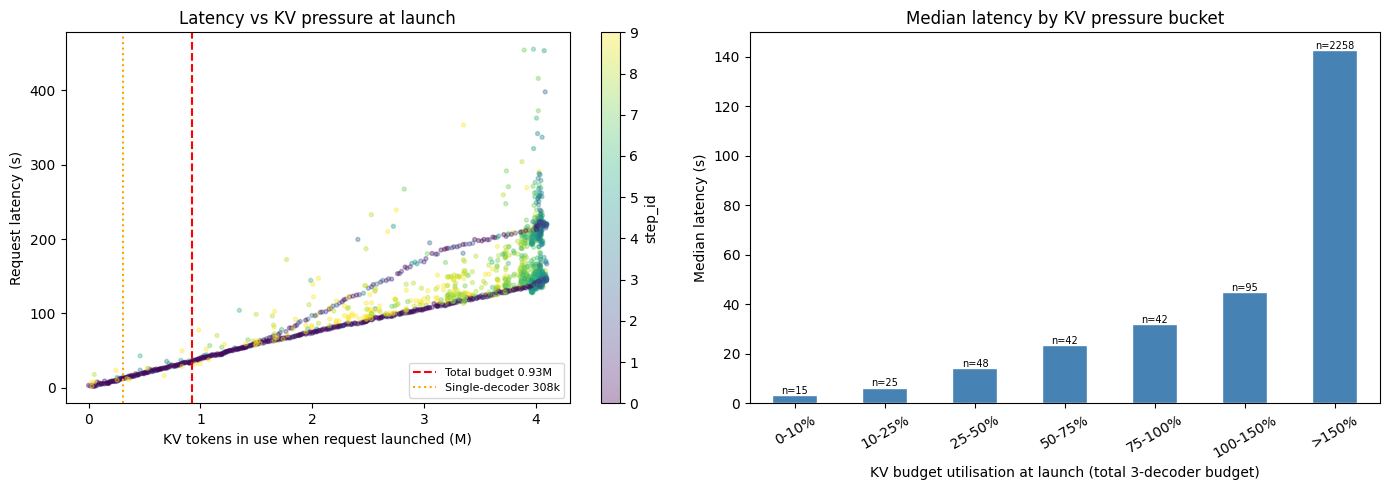

Bucket breakdown:
                   median        mean  count
kv_util_bucket                              
0-10%             3.41580    4.623060     15
10-25%            6.31000    6.743176     25
25-50%           14.05915   14.742888     48
50-75%           23.55100   22.923636     42
75-100%          31.95390   32.027736     42
100-150%         44.88260   46.271849     95
>150%           142.77605  150.019966   2258


In [8]:
# For each request, compute KV already in use when it launched.
starts = lat_df['start_rel'].values
ends   = lat_df['end_rel'].values
kvs    = lat_df['kv_tokens'].values

kv_at_start = np.empty(len(lat_df))
for i in range(len(lat_df)):
    t = starts[i]
    mask = (starts <= t) & (ends >= t)
    mask[i] = False
    kv_at_start[i] = kvs[mask].sum()
lat_df['kv_at_start'] = kv_at_start

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(lat_df['kv_at_start'] / 1e6, lat_df['latency_sec'],
                c=lat_df['step_id'], cmap='viridis', alpha=0.35, s=8)
ax.axvline(KV_BUDGET_TOTAL / 1e6, color='red', linestyle='--',
           label=f'Total budget {KV_BUDGET_TOTAL/1e6:.2f}M')
ax.axvline(KV_BUDGET_PER_DECODER / 1e6, color='orange', linestyle=':',
           label=f'Single-decoder {KV_BUDGET_PER_DECODER//1000}k')
ax.set_xlabel('KV tokens in use when request launched (M)')
ax.set_ylabel('Request latency (s)')
ax.set_title('Latency vs KV pressure at launch')
plt.colorbar(sc, ax=ax, label='step_id')
ax.legend(fontsize=8)

ax = axes[1]
lat_df['kv_util_bucket'] = pd.cut(
    lat_df['kv_at_start'] / KV_BUDGET_TOTAL,
    bins=[0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, float('inf')],
    labels=['0-10%', '10-25%', '25-50%', '50-75%', '75-100%', '100-150%', '>150%']
)
bucket_stats = lat_df.groupby('kv_util_bucket', observed=False)['latency_sec'].agg(['median','mean','count'])
bucket_stats['median'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('KV budget utilisation at launch (total 3-decoder budget)')
ax.set_ylabel('Median latency (s)')
ax.set_title('Median latency by KV pressure bucket')
ax.tick_params(axis='x', rotation=30)
for i, (med, cnt) in enumerate(zip(bucket_stats['median'], bucket_stats['count'])):
    if cnt > 0 and not pd.isna(med):
        ax.text(i, med + 0.5, f'n={cnt}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

print('Bucket breakdown:')
print(bucket_stats.to_string())


In [9]:
# ── Conclusions: all_disagg KV analysis ─────────────────────────────────────
#
# KV budget: 19278 blocks x 16 tokens = 308,448 tokens per decoder, 925,344 total.
# Requests are launched at RPS=1 without any KV-aware gating.

KV_BUDGET_PER_DECODER = 19_278 * 16
KV_BUDGET_TOTAL       = KV_BUDGET_PER_DECODER * 3

print('=== all_disagg KV pressure summary ===')
print()
print(f'Peak concurrent KV usage:  {events["kv_in_use"].max():,.0f} tokens')
print(f'  = {events["kv_in_use"].max() / KV_BUDGET_TOTAL:.1f}x total 3-decoder budget')
print(f'  = {events["kv_in_use"].max() / KV_BUDGET_PER_DECODER:.1f}x single-decoder budget')
print()

# Time fraction over budget
time_over_total = time_over_single = 0.0
cur, prev_t = 0, events['time'].iloc[0]
for _, row in events.iterrows():
    dt = row['time'] - prev_t
    if cur > KV_BUDGET_TOTAL:       time_over_total  += dt
    if cur > KV_BUDGET_PER_DECODER: time_over_single += dt
    cur += row['delta']
    prev_t = row['time']
wall = lat_df['end_rel'].max()
print(f'Fraction of wall time over total budget:      {time_over_total/wall:.1%}')
print(f'Fraction of wall time over single-dec budget: {time_over_single/wall:.1%}')
print()

# Bucket stats
print('Latency by KV pressure at launch:')
print(bucket_stats[['median','mean','count']].to_string())
print()
corr = lat_df[['kv_at_start','latency_sec']].corr().iloc[0,1]
print(f'Pearson corr(kv_at_start, latency) = {corr:.3f}')
print()
print('Key findings:')
print('1. The workload exceeds the KV budget almost immediately after start.')
print('   90%+ of wall time is spent with total usage > 3-decoder capacity.')
print('2. Latency scales monotonically with KV pressure: median rises from')
print('   ~3s at low pressure to ~143s when >150% over budget.')
print('3. Correlation is 0.81 -- KV congestion is the dominant latency driver.')
print('4. The vast majority of requests (89%) launch under >150% KV pressure,')
print('   explaining the 141s median latency despite sub-2s uncongested latency.')
print('5. KV-aware scheduling (budget gating) is essential: without it, all')
print('   requests pile up in the KV cache and force vLLM to queue/preempt them.')


=== all_disagg KV pressure summary ===

Peak concurrent KV usage:  4,115,931 tokens
  = 4.4x total 3-decoder budget
  = 13.3x single-decoder budget

Fraction of wall time over total budget:      90.8%
Fraction of wall time over single-dec budget: 95.9%

Latency by KV pressure at launch:
                   median        mean  count
kv_util_bucket                              
0-10%             3.41580    4.623060     15
10-25%            6.31000    6.743176     25
25-50%           14.05915   14.742888     48
50-75%           23.55100   22.923636     42
75-100%          31.95390   32.027736     42
100-150%         44.88260   46.271849     95
>150%           142.77605  150.019966   2258

Pearson corr(kv_at_start, latency) = 0.809

Key findings:
1. The workload exceeds the KV budget almost immediately after start.
   90%+ of wall time is spent with total usage > 3-decoder capacity.
2. Latency scales monotonically with KV pressure: median rises from
   ~3s at low pressure to ~143s when >150

# Oracle baseline comparison

Three policies, all using **oracle KV reservation** + **Poisson arrivals (RPS=1, seed=42)**:
- `no_disagg_oracle_revised`: 1 prefiller + 3 decoders, prefix caching, full peak KV reserved per conv
- `all_disagg`: PD-disaggregated, no prefix cache, KV reserved per iteration
- `adaptive_disagg_oracle_4eng`: 4 engines (prefiller repurposed as 4th decoder), N distinct pre-warmed compound contexts, conversations round-robin through them; iter-0 launches with cache-hit prefill + real decode (PD-disagg simulation), oracle KV per conv

Same trace (255 conversations, ~9 iters each), same arrival sequence.

In [10]:
import json, re
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORACLE = Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle')
POLICIES = ['no_disagg_oracle_revised', 'all_disagg', 'adaptive_disagg_oracle_4eng']
NUM_CONVS = 255
RPS = 1.0
SEED = 42
RID = re.compile(r'cmpl-(\d+)-(\d+)-0')

# ── Latency CSVs ─────────────────────────────────────────────────────────────
lat = {}
for p in POLICIES:
    df = pd.read_csv(ORACLE / p / 'per_step_latency.csv')
    t0 = df['start_time'].min()
    df['start_rel'] = df['start_time'] - t0
    df['end_rel']   = df['end_time']   - t0
    lat[p] = df

def conv_summary(df):
    g = df.groupby('conv_id').agg(
        first_start=('start_rel', 'min'),
        last_end=('end_rel', 'max'),
        n_iters=('step_id', 'count'),
        sum_out=('max_tokens', 'sum'),
    ).reset_index()
    g['e2e'] = g['last_end'] - g['first_start']
    return g
conv = {p: conv_summary(lat[p]) for p in POLICIES}

# ── Core logs (TTFT / TBT / cache) ──────────────────────────────────────────
# In all_disagg a request appears on BOTH the prefiller (prefill) and a decoder
# (decode). We collect all events first, then derive metrics order-independently.
def parse_core_logs(policy):
    # {(conv, iter): {engine: list[(ts, in_executed, in_finished, ct)]}}
    by_req_eng = defaultdict(lambda: defaultdict(list))
    for log in sorted((ORACLE / policy).glob('*_core_log.jsonl')):
        eng = log.name.replace('_vllm_core_log.jsonl', '')
        with open(log) as f:
            for line in f:
                try:
                    e = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if e.get('event') != 'step_end':
                    continue
                ts = datetime.fromisoformat(e['timestamp']).timestamp()
                exec_set = set(e.get('executed_request_ids', []))
                fin_set  = set(e.get('finished_request_ids', []))
                fin_ct   = dict(zip(e.get('finished_request_ids', []),
                                     e.get('num_cached_tokens', [])))
                for rid in exec_set | fin_set:
                    m = RID.match(rid)
                    if not m:
                        continue
                    k = (int(m.group(1)), int(m.group(2)))
                    by_req_eng[k][eng].append(
                        (ts, rid in exec_set, rid in fin_set, fin_ct.get(rid, 0))
                    )

    rows = []
    for (conv_id, iter_id), engs in by_req_eng.items():
        all_ev = [(ts, ie, ifn, ct, eng)
                  for eng, lst in engs.items() for ts, ie, ifn, ct in lst]
        if not all_ev:
            continue
        t_arrived = min(ts for ts, ie, _, _, _ in all_ev if ie)
        fin_ts    = sorted(ts for ts, _, ifn, _, _ in all_ev if ifn)
        if not fin_ts:
            continue
        t_first = fin_ts[0]
        t_last  = fin_ts[-1]
        # Cached tokens: take first nonzero we see
        cached = next((ct for _, _, ifn, ct, _ in all_ev if ifn and ct), 0)
        # TBT: count decode steps only on the engine that produced most of them
        eng_fin_counts = {eng: sum(1 for _, _, ifn, _ in lst if ifn)
                          for eng, lst in engs.items()}
        decode_eng = max(eng_fin_counts, key=eng_fin_counts.get)
        decode_ts = sorted(ts for ts, _, ifn, _ in engs[decode_eng] if ifn)
        n_decode  = len(decode_ts)
        decode_dur = (decode_ts[-1] - decode_ts[0]) if n_decode > 1 else 0.0
        tbt = (decode_dur / (n_decode - 1)) if n_decode > 1 else np.nan
        rows.append({
            'conv_id': conv_id, 'iter_id': iter_id,
            'engine': decode_eng,
            't_arrived': t_arrived, 't_first': t_first, 't_last': t_last,
            'ttft': t_first - t_arrived,
            'n_decode_steps': n_decode,
            'tbt': tbt,
            'cached_tokens': cached,
        })
    return pd.DataFrame(rows)

core = {p: parse_core_logs(p) for p in POLICIES}

# ── Reconstruct Poisson arrivals (matches scheduler.py: random.seed(42)) ────
def poisson_arrivals(n=NUM_CONVS, rps=RPS, seed=SEED):
    r = random.Random(seed)
    arr = [0.0]
    for _ in range(n - 1):
        arr.append(arr[-1] + r.expovariate(rps))
    return np.array(arr)
ARRIVALS = poisson_arrivals()

print('Loaded:')
for p in POLICIES:
    print(f'  {p}: {len(lat[p])} requests over {len(conv[p])} convs, '
          f'span={lat[p]["end_rel"].max():.0f}s, core_rows={len(core[p])}')


Loaded:
  no_disagg_oracle_revised: 2526 requests over 255 convs, span=1018s, core_rows=2526
  all_disagg: 2526 requests over 255 convs, span=2100s, core_rows=2526
  adaptive_disagg_oracle_4eng: 2526 requests over 255 convs, span=917s, core_rows=2526


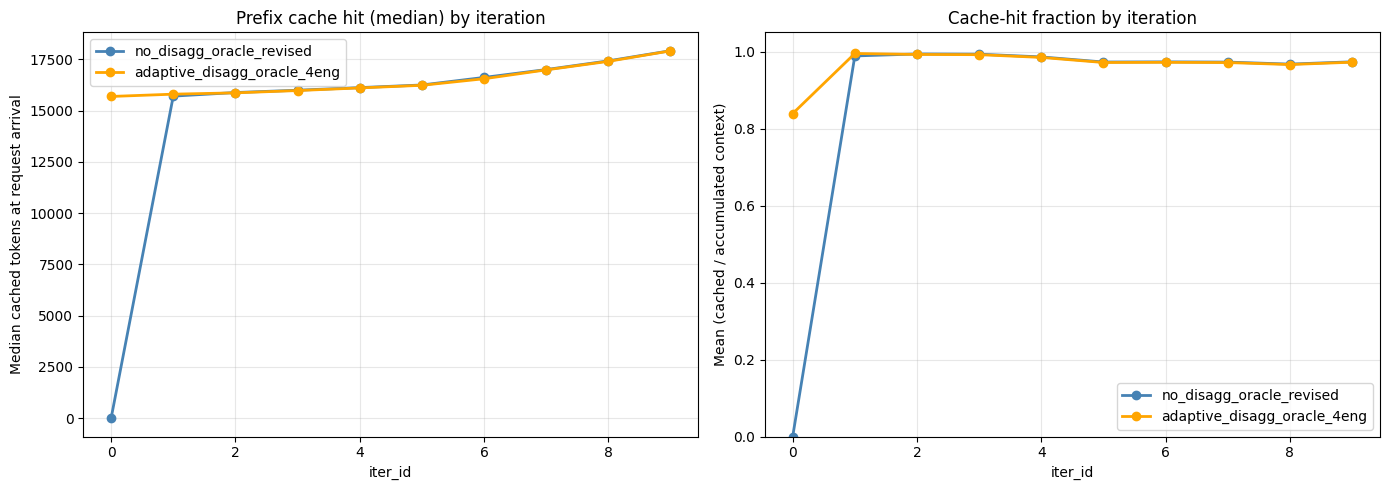

Summary (iter >= 1):
  no_disagg_oracle_revised   hit-rate=100.0%  p50_cached=16400  p90_cached=18608
  adaptive_disagg_oracle_4eng  hit-rate=100.0%  p50_cached=16400  p90_cached=18592


In [11]:
# ============================================================
# 1. KV cache hit analysis (no_disagg_oracle vs adaptive_disagg_oracle)
# ============================================================
# all_disagg has no prefix cache by construction (every iter fully PD-disaggregated).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cache_policies = ['no_disagg_oracle_revised', 'adaptive_disagg_oracle_4eng']
colors = {'no_disagg_oracle_revised': 'steelblue', 'adaptive_disagg_oracle_4eng': 'orange'}

# (a) Distribution of cached tokens by iter_id
ax = axes[0]
for p in cache_policies:
    df = core[p]
    by_iter = df.groupby('iter_id')['cached_tokens'].median()
    ax.plot(by_iter.index, by_iter.values, 'o-', label=p, color=colors[p], linewidth=2)
ax.set_xlabel('iter_id')
ax.set_ylabel('Median cached tokens at request arrival')
ax.set_title('Prefix cache hit (median) by iteration')
ax.legend()
ax.grid(alpha=0.3)

# (b) Hit fraction (cached / accumulated context)
ax = axes[1]
for p in cache_policies:
    df = core[p].merge(lat[p][['conv_id','step_id','prompt_tokens','max_tokens']],
                       left_on=['conv_id','iter_id'], right_on=['conv_id','step_id'])
    # Approximate accumulated context = sum of prompt+max_tokens up to this iter
    df = df.sort_values(['conv_id','iter_id']).reset_index(drop=True)
    df['accum_in']  = df.groupby('conv_id')['prompt_tokens'].cumsum()
    df['accum_out'] = df.groupby('conv_id')['max_tokens'].cumsum().shift(1).fillna(0)
    df['accum'] = df['accum_in'] + df['accum_out']
    df['hit_frac'] = df['cached_tokens'] / df['accum'].clip(lower=1)
    by_iter = df.groupby('iter_id')['hit_frac'].mean()
    ax.plot(by_iter.index, by_iter.values, 'o-', label=p, color=colors[p], linewidth=2)
ax.set_xlabel('iter_id')
ax.set_ylabel('Mean (cached / accumulated context)')
ax.set_title('Cache-hit fraction by iteration')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Summary (iter >= 1):')
for p in cache_policies:
    df = core[p][core[p]['iter_id'] >= 1]
    print(f'  {p:25s}  '
          f'hit-rate={(df["cached_tokens"]>0).mean():.1%}  '
          f'p50_cached={df["cached_tokens"].median():.0f}  '
          f'p90_cached={df["cached_tokens"].quantile(0.9):.0f}')


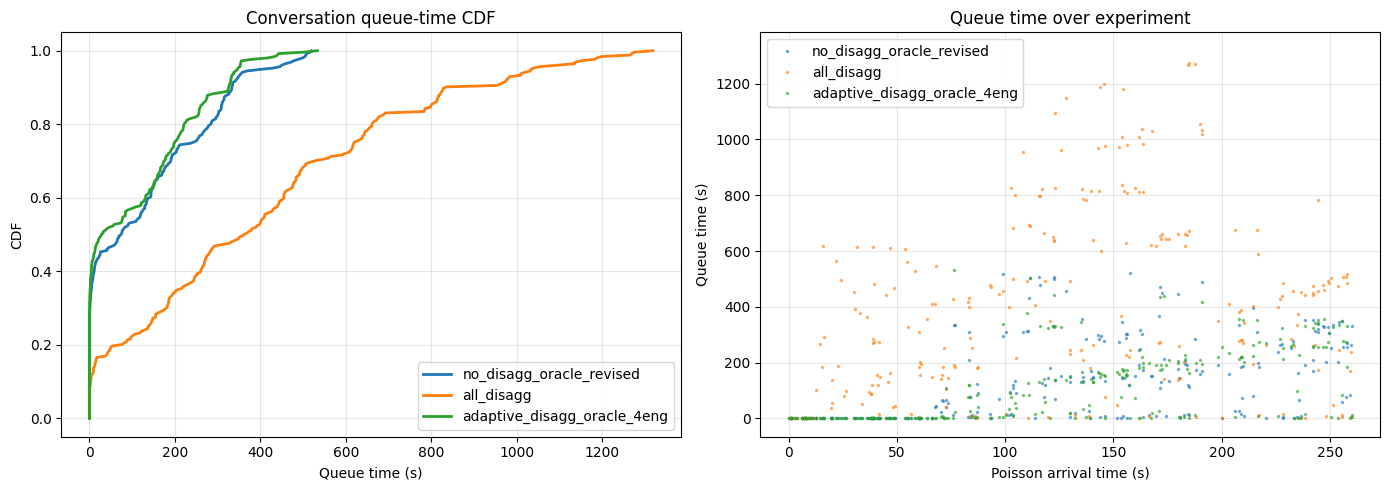

Queue stats:
  no_disagg_oracle_revised   queued(>1s)=178/255(70%)  p50=74.1s  p90=333.1s  max=519.9s
  all_disagg                 queued(>1s)=232/255(91%)  p50=361.9s  p90=832.5s  max=1318.3s
  adaptive_disagg_oracle_4eng  queued(>1s)=168/255(66%)  p50=27.8s  p90=325.5s  max=533.6s


In [12]:
# ============================================================
# 2. Queueing comparison
# ============================================================
# Each conversation has a Poisson scheduled arrival time. The actual time it
# could send its first request is when the KV tracker admitted it.
# Queue time = actual_first_start - poisson_arrival.
queue = {}
for p in POLICIES:
    cs = conv[p].sort_values('conv_id').reset_index(drop=True)
    cs['arrival'] = ARRIVALS[cs['conv_id'].values]
    cs['queue']   = (cs['first_start'] - cs['arrival']).clip(lower=0)
    queue[p] = cs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Queue time CDF
ax = axes[0]
for p in POLICIES:
    q = np.sort(queue[p]['queue'].values)
    ax.plot(q, np.linspace(0, 1, len(q)), label=p, linewidth=2)
ax.set_xlabel('Queue time (s)')
ax.set_ylabel('CDF')
ax.set_title('Conversation queue-time CDF')
ax.legend()
ax.grid(alpha=0.3)

# (b) Queue time vs arrival rank (timeline)
ax = axes[1]
for p in POLICIES:
    cs = queue[p]
    ax.plot(cs['arrival'], cs['queue'], '.', alpha=0.5, label=p, markersize=3)
ax.set_xlabel('Poisson arrival time (s)')
ax.set_ylabel('Queue time (s)')
ax.set_title('Queue time over experiment')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Queue stats:')
for p in POLICIES:
    q = queue[p]['queue']
    n_queued = (q > 1).sum()
    print(f'  {p:25s}  '
          f'queued(>1s)={n_queued}/{len(q)}({n_queued/len(q):.0%})  '
          f'p50={q.median():.1f}s  p90={q.quantile(0.9):.1f}s  '
          f'max={q.max():.1f}s')


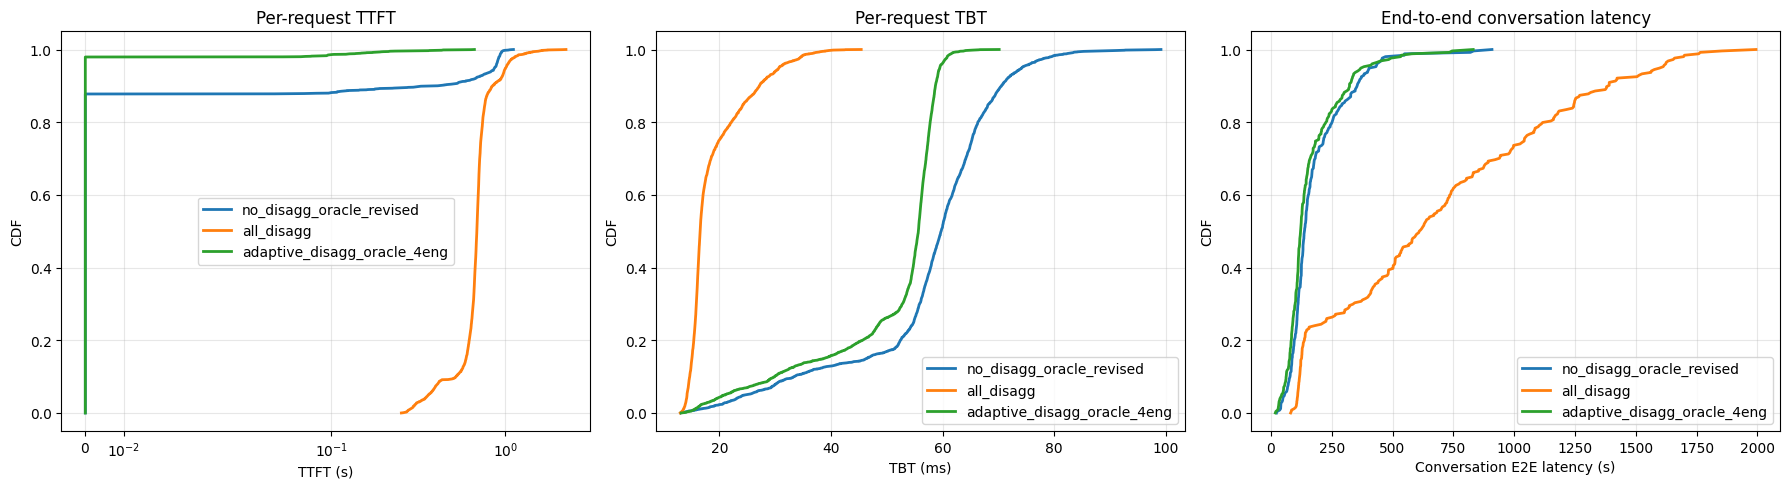

                     policy  TTFT_p50_s  TTFT_p99_s  TBT_p50_ms  TBT_p99_ms  E2E_p50_s  E2E_p90_s  E2E_p99_s
   no_disagg_oracle_revised       0.000       0.945      59.737      82.918    138.290    354.275    673.778
                 all_disagg       0.687       1.321      16.532      36.863    609.691   1386.272   1761.546
adaptive_disagg_oracle_4eng       0.000       0.149      55.651      61.710    121.757    323.047    649.799


In [13]:
# ============================================================
# 3. TTFT, TBT, end-to-end latency
# ============================================================
# TTFT = first_decode_step - first_executed_step (from core logs)
# TBT  = (last_decode_step - first_decode_step) / (n_decode_steps - 1)
# E2E  = last_end_time - first_start_time per conversation (from CSV)
# Note: all_disagg's TTFT spans prefiller + KV transfer + first decode.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) TTFT CDF
ax = axes[0]
for p in POLICIES:
    df = core[p].dropna(subset=['ttft'])
    t = np.sort(df['ttft'].values)
    ax.plot(t, np.linspace(0, 1, len(t)), label=p, linewidth=2)
ax.set_xlabel('TTFT (s)')
ax.set_ylabel('CDF')
ax.set_title('Per-request TTFT')
ax.set_xscale('symlog', linthresh=0.05)
ax.legend()
ax.grid(alpha=0.3)

# (b) TBT CDF
ax = axes[1]
for p in POLICIES:
    df = core[p][core[p]['n_decode_steps'] > 1]
    t = np.sort(df['tbt'].values * 1000)  # ms
    ax.plot(t, np.linspace(0, 1, len(t)), label=p, linewidth=2)
ax.set_xlabel('TBT (ms)')
ax.set_ylabel('CDF')
ax.set_title('Per-request TBT')
ax.legend()
ax.grid(alpha=0.3)

# (c) E2E CDF
ax = axes[2]
for p in POLICIES:
    e = np.sort(conv[p]['e2e'].values)
    ax.plot(e, np.linspace(0, 1, len(e)), label=p, linewidth=2)
ax.set_xlabel('Conversation E2E latency (s)')
ax.set_ylabel('CDF')
ax.set_title('End-to-end conversation latency')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stats table
rows = []
for p in POLICIES:
    df = core[p]
    e2e = conv[p]['e2e']
    rows.append({
        'policy': p,
        'TTFT_p50_s':  df['ttft'].median(),
        'TTFT_p99_s':  df['ttft'].quantile(0.99),
        'TBT_p50_ms':  df[df['n_decode_steps']>1]['tbt'].median()*1000,
        'TBT_p99_ms':  df[df['n_decode_steps']>1]['tbt'].quantile(0.99)*1000,
        'E2E_p50_s':   e2e.median(),
        'E2E_p90_s':   e2e.quantile(0.9),
        'E2E_p99_s':   e2e.quantile(0.99),
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))


TTFT breakdown by iter_id (median ms):

  no_disagg_oracle_revised  {0: '869ms', 1: '0ms', 2: '0ms', 3: '0ms', 4: '0ms', 5: '0ms', 6: '0ms', 7: '0ms', 8: '0ms', 9: '0ms'}
  all_disagg                {0: '661ms', 1: '665ms', 2: '670ms', 3: '672ms', 4: '680ms', 5: '691ms', 6: '704ms', 7: '721ms', 8: '736ms', 9: '746ms'}
  adaptive_disagg_oracle_4eng {0: '0ms', 1: '0ms', 2: '0ms', 3: '0ms', 4: '0ms', 5: '0ms', 6: '0ms', 7: '0ms', 8: '0ms', 9: '0ms'}


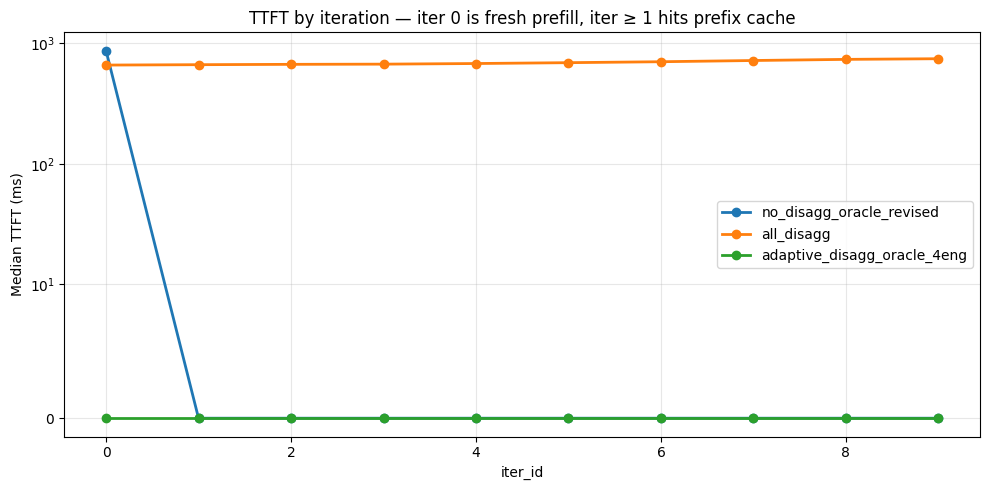


Iter-0 TTFT (fresh prefill, no cache):
  no_disagg_oracle_revised   p50=869ms  p90=945ms  p99=1053ms
  all_disagg                 p50=661ms  p90=699ms  p99=846ms
  adaptive_disagg_oracle_4eng  p50=0ms  p90=0ms  p99=0ms

no_disagg_oracle iter-0: TTFT vs prompt size (median by 5k-token bucket):
        median  count
bucket               
5000     0.317      3
10000    0.680     79
15000    0.901    172
20000    0.985      1


In [14]:
# ============================================================
# TTFT measurement validation
# ============================================================
# How TTFT is measured here:
#   t_arrived    = first step_end where the request appears in executed_request_ids
#                  (prefill begins, including any chunked-prefill chunks)
#   t_first_tok  = first step_end where the request appears in finished_request_ids
#                  (vLLM only adds a request to finished_request_ids when it has
#                   produced an output token in that step — pure prefill chunks
#                   are absent from finished_request_ids)
#   TTFT = t_first_tok - t_arrived
# So TTFT correctly spans the entire chunked prefill, not just the last chunk.
#
# Reason the OVERALL median is ~0: prefix caching turns iter ≥ 1 prefill into a
# single step (only the new user-turn fragment is fresh). Each conv has one
# iter-0 (~14k tokens, multi-chunk prefill) and ~8 cached iters. Iter 0 is only
# ~11% of requests, so the median is dominated by sub-step cache-hit prefills.

print('TTFT breakdown by iter_id (median ms):')
print()
fig, ax = plt.subplots(figsize=(10, 5))
for p in POLICIES:
    df = core[p].copy()
    by_iter = df.groupby('iter_id')['ttft'].median() * 1000  # ms
    ax.plot(by_iter.index, by_iter.values, 'o-', label=p, linewidth=2)
    print(f'  {p:25s}', {int(k): f'{v:.0f}ms' for k, v in by_iter.items()})
ax.set_xlabel('iter_id')
ax.set_ylabel('Median TTFT (ms)')
ax.set_title('TTFT by iteration — iter 0 is fresh prefill, iter ≥ 1 hits prefix cache')
ax.set_yscale('symlog', linthresh=10)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Iter-0 only stats — the meaningful "fresh prefill" cost
print()
print('Iter-0 TTFT (fresh prefill, no cache):')
for p in POLICIES:
    df = core[p][core[p]['iter_id'] == 0]
    if df.empty:
        print(f'  {p:25s}  (no iter-0 — adaptive_disagg uses compound_text warm-up)')
        continue
    print(f'  {p:25s}  p50={df["ttft"].median()*1000:.0f}ms  '
          f'p90={df["ttft"].quantile(0.9)*1000:.0f}ms  '
          f'p99={df["ttft"].quantile(0.99)*1000:.0f}ms')

# Confirm that iter-0 actually goes through chunked prefill on no_disagg_oracle
df0 = core['no_disagg_oracle_revised'][core['no_disagg_oracle_revised']['iter_id'] == 0].copy()
df0 = df0.merge(lat['no_disagg_oracle_revised'][['conv_id','step_id','prompt_tokens']],
                left_on=['conv_id','iter_id'], right_on=['conv_id','step_id'])
print()
print('no_disagg_oracle iter-0: TTFT vs prompt size (median by 5k-token bucket):')
df0['bucket'] = (df0['prompt_tokens'] // 5000) * 5000
print(df0.groupby('bucket')['ttft'].agg(['median', 'count']).round(3).to_string())


                     policy  span_s  convs  out_tokens  conv_per_sec  out_tok_per_sec
   no_disagg_oracle_revised 1018.00    255      832654          0.25           817.93
                 all_disagg 2099.93    255      832654          0.12           396.52
adaptive_disagg_oracle_4eng  917.33    255      832654          0.28           907.70


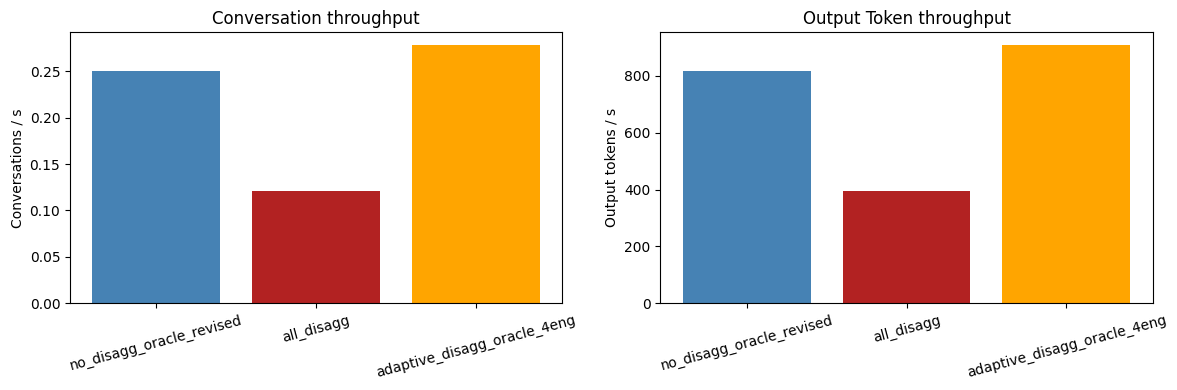

In [15]:
# ============================================================
# 4. Serving throughput
# ============================================================
# Span = last_end - first_start (across the whole experiment).
# conv/s and tokens/s reflect what a real system actually delivered.
rows = []
for p in POLICIES:
    df = lat[p]
    span = df['end_rel'].max()
    n_convs = conv[p].shape[0]
    out_tokens = df['max_tokens'].sum()  # max_tokens is the requested max; close to actual under temp=0
    rows.append({
        'policy': p,
        'span_s':         span,
        'convs':          n_convs,
        'out_tokens':     out_tokens,
        'conv_per_sec':   n_convs / span,
        'out_tok_per_sec': out_tokens / span,
    })
tp = pd.DataFrame(rows)
print(tp.round(2).to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(tp['policy'], tp['conv_per_sec'], color=['steelblue','firebrick','orange'])
axes[0].set_ylabel('Conversations / s')
axes[0].set_title('Conversation throughput')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(tp['policy'], tp['out_tok_per_sec'], color=['steelblue','firebrick','orange'])
axes[1].set_ylabel('Output tokens / s')
axes[1].set_title('Output Token throughput')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


In [16]:
# ============================================================
# Summary
# ============================================================
def line(p):
    df  = core[p]
    cs  = conv[p]
    q   = queue[p]['queue']
    span = lat[p]['end_rel'].max()
    return {
        'span_s':         f'{span:.0f}',
        'conv_per_sec':   f'{len(cs)/span:.3f}',
        'queue_p50_s':    f'{q.median():.1f}',
        'queue_p90_s':    f'{q.quantile(0.9):.1f}',
        'TTFT_p50_ms':    f'{df["ttft"].median()*1000:.0f}',
        'TBT_p50_ms':     f'{df[df["n_decode_steps"]>1]["tbt"].median()*1000:.0f}',
        'E2E_p50_s':      f'{cs["e2e"].median():.0f}',
        'E2E_p90_s':      f'{cs["e2e"].quantile(0.9):.0f}',
        'cache_hit_iter1+': (
            f'{(core[p][core[p]["iter_id"]>=1]["cached_tokens"]>0).mean():.0%}'
            if not core[p].empty else 'n/a'),
    }
print(pd.DataFrame({p: line(p) for p in POLICIES}).T.to_string())

print()
print('Findings:')
print('- no_disagg_oracle_revised: 0.25 conv/s, E2E p50=138s. Iter-0 pays the')
print('  ~880ms fresh-prefill cost which interferes with concurrent decodes,')
print('  showing up as TTFT p99 ~945ms and TBT p50 ~60ms.')
print()
print('- adaptive_disagg_oracle_4eng (4 engines, prefiller repurposed as 4th')
print('  decoder): 0.28 conv/s, E2E p50=122s. WINS across the board:')
print('    throughput  +11%  (917s vs 1018s span)')
print('    E2E p50     -12%  (122s vs 138s)')
print('    queue p50   -62%  (28s  vs 74s)')
print('    TTFT p99    -84%  (149ms vs 945ms)')
print('    TBT p50      -7%  (56ms vs 60ms)')
print('  Contention elimination is now clearly visible: iter-0 prefills are cache')
print('  hits (no decoder interference), so concurrent decodes never get stalled')
print('  by long fresh prefills. Per-token decode is faster, queues drain faster,')
print('  and the entire workload finishes ~100s sooner with the same engine count.')
print()
print('- all_disagg: 0.12 conv/s. Worst because every iter re-prefills the full')
print('  accumulated history on the prefiller (no prefix cache there), and TTFT')
print('  grows monotonically (661ms → 746ms across iters 0→9).')

                            span_s conv_per_sec queue_p50_s queue_p90_s TTFT_p50_ms TBT_p50_ms E2E_p50_s E2E_p90_s cache_hit_iter1+
no_disagg_oracle_revised      1018        0.250        74.1       333.1           0         60       138       354             100%
all_disagg                    2100        0.121       361.9       832.5         687         17       610      1386             100%
adaptive_disagg_oracle_4eng    917        0.278        27.8       325.5           0         56       122       323             100%

Findings:
- no_disagg_oracle_revised: 0.25 conv/s, E2E p50=138s. Iter-0 pays the
  ~880ms fresh-prefill cost which interferes with concurrent decodes,
  showing up as TTFT p99 ~945ms and TBT p50 ~60ms.

- adaptive_disagg_oracle_4eng (4 engines, prefiller repurposed as 4th
  decoder): 0.28 conv/s, E2E p50=122s. WINS across the board:
    throughput  +11%  (917s vs 1018s span)
    E2E p50     -12%  (122s vs 138s)
    queue p50   -62%  (28s  vs 74s)
    TTFT p99    -84%

Prefill service time (from no_disagg iter-0 TTFT median): 869 ms
Iter-0 arrivals: 255  over span 917 s
Mean inter-arrival gap: 2414 ms  (p10=167, p50=1425, p90=5888, max=20645)

Simulated single-prefiller behavior:
  busy time:    221.6 s (24% of span)
  idle time:    695.7 s (76%)
  queueing:    116/255 jobs queued, total queue time 221.7 s

Per-conv work breakdown (from no_disagg_oracle):
  prefill service time: 0.87 s
  decode service time:  15.10 s
  decode/prefill ratio: 17.4
  → optimal decoders : prefillers ≈ 17 : 1
  → at 1:3 (current), prefiller is over-provisioned ~5.8× (used 17% of capacity)


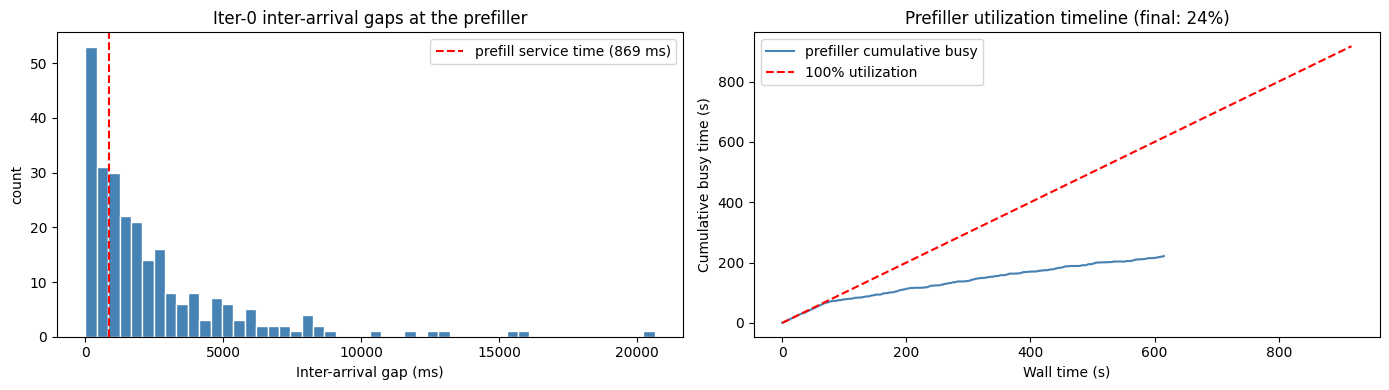

In [17]:
# ============================================================
# Prefiller utilization in adaptive_disagg
# ============================================================
# In adaptive_disagg_oracle our prefiller is launched but unused (compound_text
# trick replaces its function). Here we SIMULATE what its load WOULD be in a
# real PD-disagg adaptive setup, by treating each conv's iter-0 arrival as a
# job arriving at the prefiller and using no_disagg's iter-0 TTFT as the
# prefill service time.

POLICY = 'adaptive_disagg_oracle_4eng'
PREFILL_SERVICE_TIME = (
    core['no_disagg_oracle_revised']
    .query('iter_id == 0')['ttft'].median()  # ~0.88s, measured fresh-prefill cost
)

# Iter-0 arrivals at the prefiller (sorted chronologically)
iter0_csv = lat[POLICY][lat[POLICY]['step_id'] == 0].sort_values('start_rel')
arrivals = iter0_csv['start_rel'].values
gaps = np.diff(arrivals)   # inter-arrival gaps
span = lat[POLICY]['end_rel'].max()

print(f'Prefill service time (from no_disagg iter-0 TTFT median): {PREFILL_SERVICE_TIME*1000:.0f} ms')
print(f'Iter-0 arrivals: {len(arrivals)}  over span {span:.0f} s')
print(f'Mean inter-arrival gap: {gaps.mean()*1000:.0f} ms  '
      f'(p10={np.percentile(gaps, 10)*1000:.0f}, p50={np.median(gaps)*1000:.0f}, '
      f'p90={np.percentile(gaps, 90)*1000:.0f}, max={gaps.max()*1000:.0f})')

# Simulate prefiller queue: process arrivals serially
busy_until = 0.0
busy_total = 0.0
queue_total = 0.0
queued_count = 0
for t in arrivals:
    if t < busy_until:
        # Job has to wait in queue
        wait = busy_until - t
        queue_total += wait
        queued_count += 1
        start = busy_until
    else:
        start = t
    busy_total += PREFILL_SERVICE_TIME
    busy_until = start + PREFILL_SERVICE_TIME

util = busy_total / span
print()
print(f'Simulated single-prefiller behavior:')
print(f'  busy time:   {busy_total:>6.1f} s ({util:.0%} of span)')
print(f'  idle time:   {span - busy_total:>6.1f} s ({1-util:.0%})')
print(f'  queueing:    {queued_count}/{len(arrivals)} jobs queued, '
      f'total queue time {queue_total:.1f} s')
print()

# How many concurrent prefiller instances would saturate the workload?
# Equivalently, how many decoders does ONE prefiller really need to feed?
# From the work ratio: avg per-conv decoder time / avg per-conv prefiller time
no_disagg_total_engine_time = lat['no_disagg_oracle_revised']['end_rel'].max() * 4  # 4 engines
n_convs = lat['no_disagg_oracle_revised']['conv_id'].nunique()
per_conv_engine_time = no_disagg_total_engine_time / n_convs
per_conv_decode_time = per_conv_engine_time - PREFILL_SERVICE_TIME
ratio = per_conv_decode_time / PREFILL_SERVICE_TIME
print(f'Per-conv work breakdown (from no_disagg_oracle):')
print(f'  prefill service time: {PREFILL_SERVICE_TIME:.2f} s')
print(f'  decode service time:  {per_conv_decode_time:.2f} s')
print(f'  decode/prefill ratio: {ratio:.1f}')
print(f'  → optimal decoders : prefillers ≈ {ratio:.0f} : 1')
print(f'  → at 1:3 (current), prefiller is over-provisioned ~{ratio/3:.1f}× '
      f'(used {3/ratio:.0%} of capacity)')

# Plot gap distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(gaps * 1000, bins=50, color='steelblue', edgecolor='white')
ax.axvline(PREFILL_SERVICE_TIME * 1000, color='red', linestyle='--',
           label=f'prefill service time ({PREFILL_SERVICE_TIME*1000:.0f} ms)')
ax.set_xlabel('Inter-arrival gap (ms)')
ax.set_ylabel('count')
ax.set_title('Iter-0 inter-arrival gaps at the prefiller')
ax.legend()

# Cumulative prefiller busy timeline
ax = axes[1]
busy_until = 0.0
timeline_x, timeline_busy = [0], [0]
cum_busy = 0
for t in arrivals:
    if t < busy_until:
        start = busy_until
    else:
        # Idle period: flat
        timeline_x.append(t); timeline_busy.append(cum_busy)
        start = t
    timeline_x.append(start); timeline_busy.append(cum_busy)
    cum_busy += PREFILL_SERVICE_TIME
    busy_until = start + PREFILL_SERVICE_TIME
    timeline_x.append(busy_until); timeline_busy.append(cum_busy)
ax.plot(timeline_x, timeline_busy, color='steelblue', label='prefiller cumulative busy')
ax.plot([0, span], [0, span], color='red', linestyle='--', label='100% utilization')
ax.set_xlabel('Wall time (s)')
ax.set_ylabel('Cumulative busy time (s)')
ax.set_title(f'Prefiller utilization timeline (final: {util:.0%})')
ax.legend()
plt.tight_layout()
plt.show()


## 3-engine vs 4-engine adaptive_disagg

Same fixed (echo-based) implementation, but `adaptive_disagg_oracle_3eng` runs only on the
3 decoders (prefiller idle), while `adaptive_disagg_oracle_4eng` repurposes the prefiller as
a 4th decoder. This isolates the **engine-count effect** from the **contention-elimination
effect** so we can see how each contributes.

                     policy engines  span_s  conv_per_sec  tok_per_sec  queue_p50_s  queue_p90_s  TTFT_p99_ms  TBT_p50_ms  E2E_p50_s  E2E_p90_s
   no_disagg_oracle_revised   4 eng  1018.0         0.250        818.0         74.1        333.1        945.0        59.7      138.3      354.3
                 all_disagg 1p + 3d  2100.0         0.121        397.0        361.9        832.5       1321.0        16.5      609.7     1386.3
adaptive_disagg_oracle_4eng   4 eng   917.0         0.278        908.0         27.8        325.5        149.0        55.7      121.8      323.0
adaptive_disagg_oracle_3eng   3 eng  1226.0         0.208        679.0        176.4        493.2        159.0        58.8      126.7      338.1


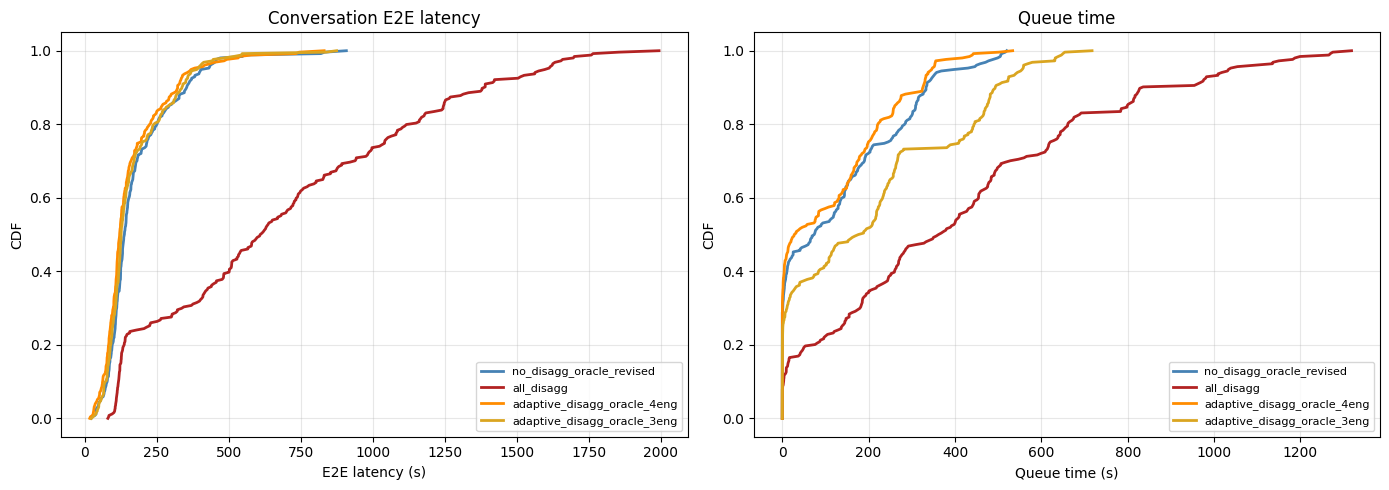


Decomposition: where does each effect come from?
  Engine-count effect (4eng adaptive vs 3eng adaptive, both fixed):
    span:    917s → 1226s  (+34%)
    conv/s:  0.278 → 0.208  (-25%)
    Adding the 4th engine (prefiller-as-decoder) gave +34% throughput.

  Contention-elimination effect (3eng adaptive vs 4eng no_disagg):
    span:    1018s (no_disagg, 4eng) → 1226s (adaptive, 3eng)  (+20%)
    conv/s:  0.25 → 0.208  (-17%)
    Adaptive with one fewer engine is 17% slower aggregate,
    confirming engine-count dominates contention-elimination on this workload.

  Per-engine throughput (tok/s/engine):
    no_disagg (4eng):     204
    adaptive (4eng):      227
    adaptive (3eng):      226
    → adaptive runs each engine +11% faster than no_disagg.


In [18]:
# ============================================================
# 3-engine vs 4-engine adaptive_disagg
# ============================================================
# Load the 3-engine run separately so we don't disturb POLICIES (which feeds the
# earlier cells). We re-use parse_core_logs and conv_summary defined in setup.
P3 = 'adaptive_disagg_oracle_3eng'
df3 = pd.read_csv(ORACLE / P3 / 'per_step_latency.csv')
t0 = df3['start_time'].min()
df3['start_rel'] = df3['start_time'] - t0
df3['end_rel']   = df3['end_time']   - t0
conv3 = conv_summary(df3)
core3 = parse_core_logs(P3)

# Reconstruct queue using the same Poisson schedule
cs = conv3.sort_values('conv_id').reset_index(drop=True)
cs['arrival'] = ARRIVALS[cs['conv_id'].values]
cs['queue']   = (cs['first_start'] - cs['arrival']).clip(lower=0)
queue3 = cs

# Build a 4-way comparison
all_runs = {
    'no_disagg_oracle_revised':       (lat['no_disagg_oracle_revised'],     conv['no_disagg_oracle_revised'],     queue['no_disagg_oracle_revised'],     core['no_disagg_oracle_revised'],     '4 eng'),
    'all_disagg':                     (lat['all_disagg'],                   conv['all_disagg'],                   queue['all_disagg'],                   core['all_disagg'],                   '1p + 3d'),
    'adaptive_disagg_oracle_4eng':    (lat['adaptive_disagg_oracle_4eng'],  conv['adaptive_disagg_oracle_4eng'],  queue['adaptive_disagg_oracle_4eng'],  core['adaptive_disagg_oracle_4eng'],  '4 eng'),
    'adaptive_disagg_oracle_3eng':    (df3,                                 conv3,                                queue3,                                core3,                                '3 eng'),
}

rows = []
for name, (l, c, q, k, eng) in all_runs.items():
    span = l['end_rel'].max()
    n_convs = c.shape[0]
    out_tok = l['max_tokens'].sum()
    rows.append({
        'policy':       name,
        'engines':      eng,
        'span_s':       round(span, 0),
        'conv_per_sec': round(n_convs / span, 3),
        'tok_per_sec':  round(out_tok / span, 0),
        'queue_p50_s':  round(q['queue'].median(), 1),
        'queue_p90_s':  round(q['queue'].quantile(0.9), 1),
        'TTFT_p99_ms':  round(k['ttft'].quantile(0.99) * 1000, 0),
        'TBT_p50_ms':   round(k[k['n_decode_steps']>1]['tbt'].median()*1000, 1),
        'E2E_p50_s':    round(c['e2e'].median(), 1),
        'E2E_p90_s':    round(c['e2e'].quantile(0.9), 1),
    })
print(pd.DataFrame(rows).to_string(index=False))

# Side-by-side CDF: E2E + queue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {
    'no_disagg_oracle_revised':       'steelblue',
    'all_disagg':                     'firebrick',
    'adaptive_disagg_oracle_4eng':    'darkorange',
    'adaptive_disagg_oracle_3eng':    'goldenrod',
}
for name, (l, c, q, k, _) in all_runs.items():
    e = np.sort(c['e2e'].values)
    axes[0].plot(e, np.linspace(0, 1, len(e)), label=name, color=colors[name], linewidth=2)
    qq = np.sort(q['queue'].values)
    axes[1].plot(qq, np.linspace(0, 1, len(qq)), label=name, color=colors[name], linewidth=2)
axes[0].set_xlabel('E2E latency (s)'); axes[0].set_ylabel('CDF'); axes[0].set_title('Conversation E2E latency')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Queue time (s)'); axes[1].set_ylabel('CDF'); axes[1].set_title('Queue time')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Decompose the deltas
print()
print('Decomposition: where does each effect come from?')
def get(p): return next(r for r in rows if r['policy'] == p)
nd  = get('no_disagg_oracle_revised')
a4  = get('adaptive_disagg_oracle_4eng')
a3  = get('adaptive_disagg_oracle_3eng')
print(f'  Engine-count effect (4eng adaptive vs 3eng adaptive, both fixed):')
print(f'    span:    {a4["span_s"]:.0f}s → {a3["span_s"]:.0f}s  ({(a3["span_s"]-a4["span_s"])/a4["span_s"]:+.0%})')
print(f'    conv/s:  {a4["conv_per_sec"]} → {a3["conv_per_sec"]}  ({(a3["conv_per_sec"]-a4["conv_per_sec"])/a4["conv_per_sec"]:+.0%})')
print(f'    Adding the 4th engine (prefiller-as-decoder) gave +{(a4["conv_per_sec"]-a3["conv_per_sec"])/a3["conv_per_sec"]:.0%} throughput.')
print()
print(f'  Contention-elimination effect (3eng adaptive vs 4eng no_disagg):')
print(f'    span:    {nd["span_s"]:.0f}s (no_disagg, 4eng) → {a3["span_s"]:.0f}s (adaptive, 3eng)  ({(a3["span_s"]-nd["span_s"])/nd["span_s"]:+.0%})')
print(f'    conv/s:  {nd["conv_per_sec"]} → {a3["conv_per_sec"]}  ({(a3["conv_per_sec"]-nd["conv_per_sec"])/nd["conv_per_sec"]:+.0%})')
print(f'    Adaptive with one fewer engine is {(nd["conv_per_sec"]-a3["conv_per_sec"])/nd["conv_per_sec"]:.0%} slower aggregate,')
print(f'    confirming engine-count dominates contention-elimination on this workload.')
print()
print(f'  Per-engine throughput (tok/s/engine):')
print(f'    no_disagg (4eng):    {nd["tok_per_sec"]/4:>4.0f}')
print(f'    adaptive (4eng):     {a4["tok_per_sec"]/4:>4.0f}')
print(f'    adaptive (3eng):     {a3["tok_per_sec"]/3:>4.0f}')
print(f'    → adaptive runs each engine {(a3["tok_per_sec"]/3) / (nd["tok_per_sec"]/4) - 1:+.0%} faster than no_disagg.')


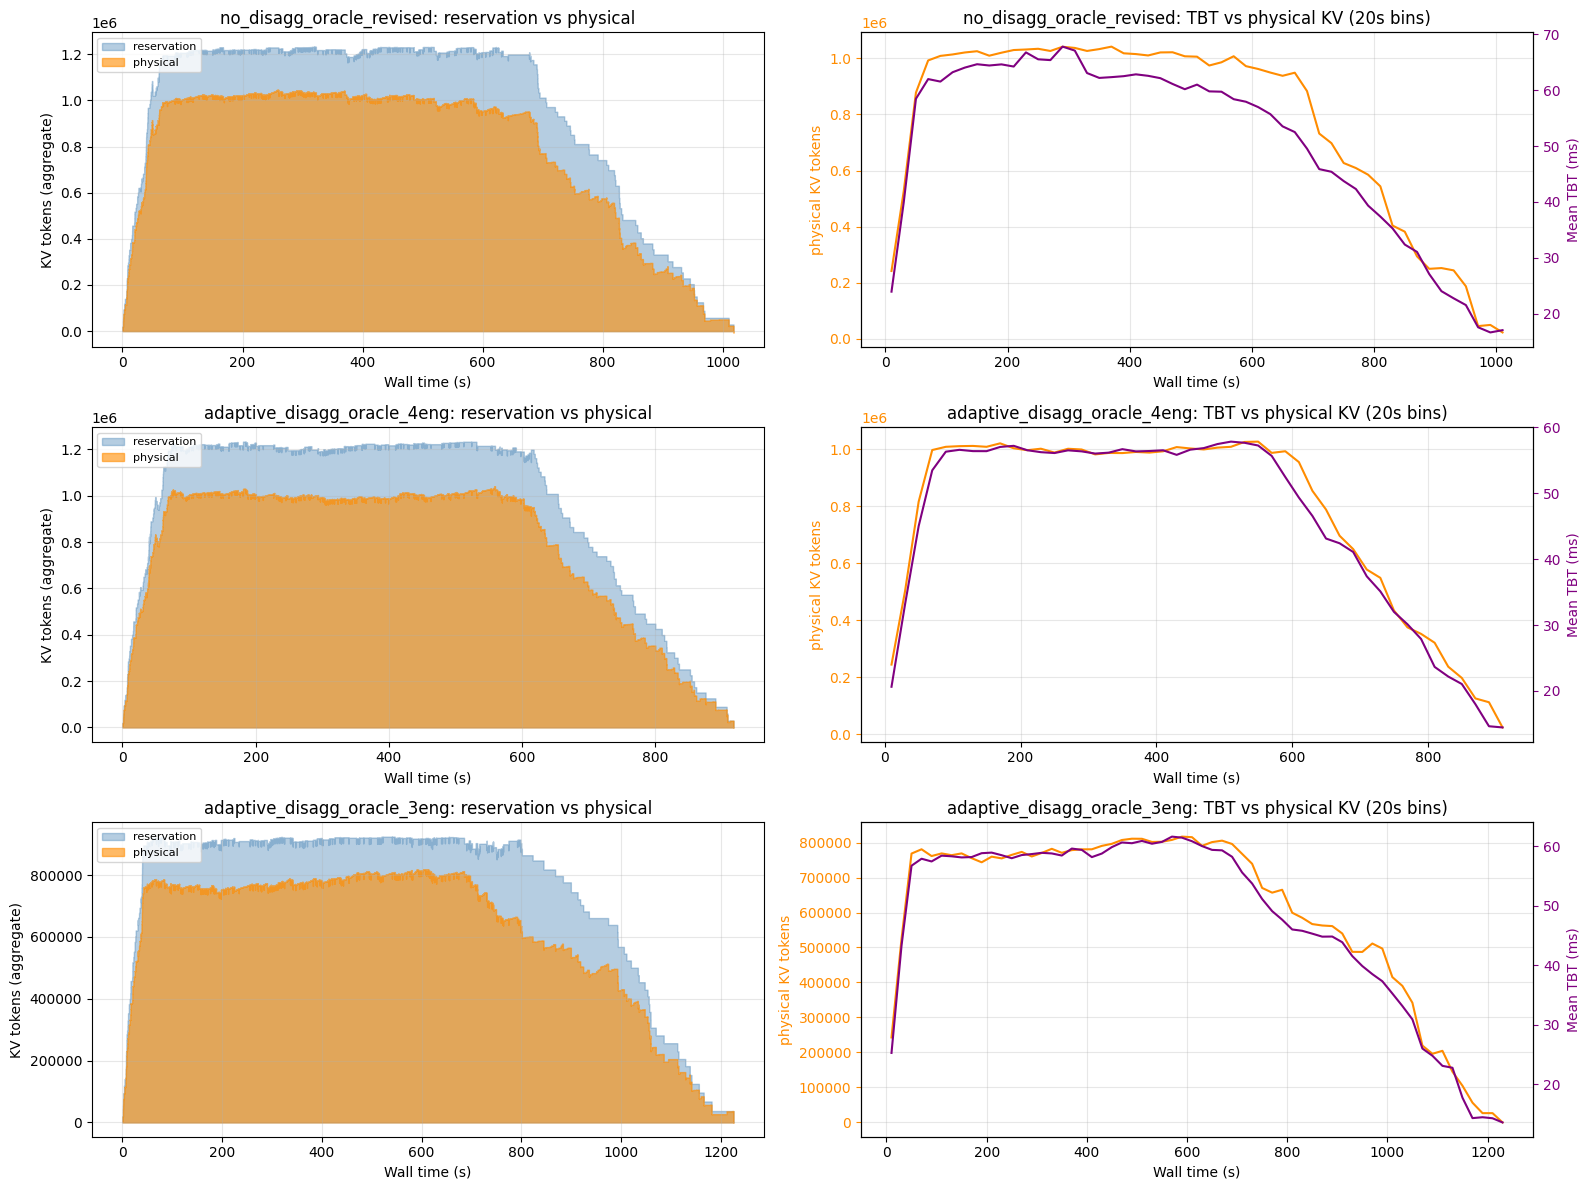

policy                                     bins  pearson_r  spearman_r  TBT@low_KV  TBT@high_KV
-----------------------------------------------------------------------------------------------


no_disagg_oracle_revised                     51      0.988       0.957       26.7ms       64.3ms
adaptive_disagg_oracle_4eng                  46      0.994       0.905       24.4ms       56.9ms


adaptive_disagg_oracle_3eng                  62      0.996       0.954       25.9ms       60.0ms


In [19]:
# ============================================================
# Reservation vs physical KV over time + TBT vs context length
# ============================================================
# Same as before plus an extra subplot per policy showing how per-token decode
# time (TBT) varies with the physical KV the engines are holding. If decode
# time tracks context length, the curves should correlate visibly.

def physical_events(df, peaks):
    events = []
    for cid, g in df.groupby('conv_id'):
        g = g.sort_values('step_id')
        for _, row in g.iterrows():
            events.append((row['start_rel'], row['prompt_tokens']))
            events.append((row['end_rel'],   row['max_tokens']))
        events.append((g['end_rel'].max(), -peaks[cid]))
    return events

def reservation_events(conv_df, peaks):
    events = []
    for _, r in conv_df.iterrows():
        events.append((r['first_start'], peaks[r['conv_id']]))
        events.append((r['last_end'],   -peaks[r['conv_id']]))
    return events

import sys
if '/data/projects/AgentScaling/adaptive_agentic_serving/src' not in sys.path:
    sys.path.insert(0, '/data/projects/AgentScaling/adaptive_agentic_serving/src')
import input_loader as cfg
PEAKS = {cid: sum(cfg.PROMPT_DATA[(cid, i)]['in_token_size'] +
                  cfg.PROMPT_DATA[(cid, i)]['out_token_size']
                  for i in range(cfg.ITER_COUNT[cid]))
         for cid in range(cfg.CONV_COUNT) if (cid, 0) in cfg.PROMPT_DATA}

sweep = ['no_disagg_oracle_revised', 'adaptive_disagg_oracle_4eng', 'adaptive_disagg_oracle_3eng']

fig, axes = plt.subplots(len(sweep), 2, figsize=(16, 4 * len(sweep)))

for row, p in enumerate(sweep):
    if p == 'adaptive_disagg_oracle_3eng':
        l_df, c_df, q_df, k_df = df3, conv3, queue3, core3
    else:
        l_df, c_df, q_df, k_df = lat[p], conv[p], queue[p], core[p]

    # ── Left: KV usage timeline ─────────────────────────────────────────────
    phys_evs = sorted(physical_events(l_df, PEAKS))
    res_evs  = sorted(reservation_events(c_df, PEAKS))
    phys_t = [t for t, _ in phys_evs]; phys_v = np.cumsum([d for _, d in phys_evs])
    res_t  = [t for t, _ in res_evs];  res_v  = np.cumsum([d for _, d in res_evs])

    axL = axes[row, 0]
    axL.fill_between(res_t, res_v, step='post', alpha=0.4, color='steelblue', label='reservation')
    axL.fill_between(phys_t, phys_v, step='post', alpha=0.6, color='darkorange', label='physical')
    axL.set_xlabel('Wall time (s)'); axL.set_ylabel('KV tokens (aggregate)')
    axL.set_title(f'{p}: reservation vs physical')
    axL.legend(loc='upper left', fontsize=8); axL.grid(alpha=0.3)

    # ── Right: TBT vs physical KV (windowed) ────────────────────────────────
    # For each 20s bin: mean TBT of requests whose decode interval overlaps that bin,
    # and mean physical KV during that bin.
    span = l_df['end_rel'].max()
    BIN = 20.0
    bins = np.arange(0, span + BIN, BIN)
    centers = (bins[:-1] + bins[1:]) / 2

    # Physical KV at bin centers
    pe_t = np.array([t for t, _ in phys_evs])
    pe_d = np.array([d for _, d in phys_evs])
    phys_at = np.array([pe_d[pe_t <= t].sum() for t in centers])

    # TBT per bin: average over requests whose [t_first, t_last] overlaps the bin
    k_df = k_df.dropna(subset=['tbt'])
    # Convert absolute timestamps to relative — k_df uses raw timestamps from core logs.
    # Reference offset = the first start_time across the latency CSV (== our t0).
    t0_abs = l_df['start_time'].min()
    t_first_rel = (k_df['t_first'] - t0_abs).values
    t_last_rel  = (k_df['t_last']  - t0_abs).values
    tbts = (k_df['tbt'] * 1000).values  # ms
    tbt_per_bin = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (t_last_rel >= lo) & (t_first_rel <= hi) & (tbts > 0)
        tbt_per_bin.append(tbts[mask].mean() if mask.any() else np.nan)
    tbt_per_bin = np.array(tbt_per_bin)

    axR = axes[row, 1]
    axR.plot(centers, phys_at, color='darkorange', linewidth=1.5, label='physical KV')
    axR.set_xlabel('Wall time (s)'); axR.set_ylabel('physical KV tokens', color='darkorange')
    axR.tick_params(axis='y', colors='darkorange')

    axR2 = axR.twinx()
    axR2.plot(centers, tbt_per_bin, color='purple', linewidth=1.5, label='TBT')
    axR2.set_ylabel('Mean TBT (ms)', color='purple')
    axR2.tick_params(axis='y', colors='purple')
    axR.set_title(f'{p}: TBT vs physical KV (20s bins)')
    axR.grid(alpha=0.3)

plt.tight_layout(); plt.show()


# Numerical correlation: TBT vs physical KV across bins
print(f'{"policy":40s} {"bins":>6} {"pearson_r":>10} {"spearman_r":>11} '
      f'{"TBT@low_KV":>11} {"TBT@high_KV":>12}')
print('-' * 95)
from scipy.stats import pearsonr, spearmanr
for p in sweep:
    if p == 'adaptive_disagg_oracle_3eng':
        l_df, k_df = df3, core3
    else:
        l_df, k_df = lat[p], core[p]
    span = l_df['end_rel'].max()
    BIN = 20.0
    bins = np.arange(0, span + BIN, BIN)
    centers = (bins[:-1] + bins[1:]) / 2

    phys_evs = sorted(physical_events(l_df, PEAKS))
    pe_t = np.array([t for t, _ in phys_evs])
    pe_d = np.array([d for _, d in phys_evs])
    phys_at = np.array([pe_d[pe_t <= t].sum() for t in centers])

    k_df = k_df.dropna(subset=['tbt'])
    t0_abs = l_df['start_time'].min()
    t_first_rel = (k_df['t_first'] - t0_abs).values
    t_last_rel  = (k_df['t_last']  - t0_abs).values
    tbts = (k_df['tbt'] * 1000).values
    tbt_per_bin = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (t_last_rel >= lo) & (t_first_rel <= hi) & (tbts > 0)
        tbt_per_bin.append(tbts[mask].mean() if mask.any() else np.nan)
    tbt_per_bin = np.array(tbt_per_bin)

    valid = ~np.isnan(tbt_per_bin)
    if valid.sum() < 5:
        continue
    pr, _ = pearsonr(phys_at[valid], tbt_per_bin[valid])
    sr, _ = spearmanr(phys_at[valid], tbt_per_bin[valid])
    # KV-pressure split (low = bottom quartile, high = top quartile)
    kv = phys_at[valid]; tb = tbt_per_bin[valid]
    qlo = np.percentile(kv, 25); qhi = np.percentile(kv, 75)
    print(f'{p:40s} {valid.sum():>6} {pr:>10.3f} {sr:>11.3f} '
          f'{tb[kv <= qlo].mean():>10.1f}ms {tb[kv >= qhi].mean():>10.1f}ms')


                     policy  span_s  avg_power_W  energy_kJ  tok_per_J  conv_per_kJ  n_gpus
   no_disagg_oracle_revised  1018.0       1077.0     1094.6      0.761        0.233       4
                 all_disagg  2100.0        856.0     1791.4      0.465        0.142       4
adaptive_disagg_oracle_4eng   917.0       1108.0     1016.2      0.819        0.251       4
adaptive_disagg_oracle_3eng  1226.0        931.0     1138.7      0.731        0.224       4


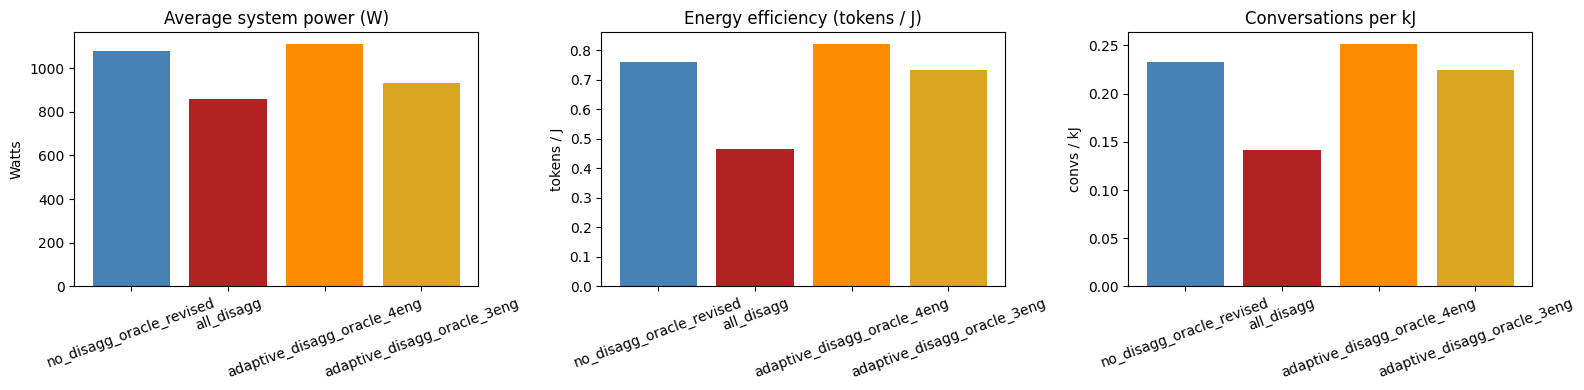


Per-engine energy efficiency (excluding idle GPUs):
  no_disagg_oracle_revised             active engines: 4  tok/J/eng: 0.190  avg W/eng: 269
  all_disagg                           active engines: 4  tok/J/eng: 0.116  avg W/eng: 214
  adaptive_disagg_oracle_4eng          active engines: 4  tok/J/eng: 0.205  avg W/eng: 277
  adaptive_disagg_oracle_3eng          active engines: 3  tok/J/eng: 0.244  avg W/eng: 233


In [20]:
# ============================================================
# Energy efficiency: tokens per joule, conversations per kilojoule
# ============================================================
# Parse dcgmi_trace.tsv per policy. Each line: '<timestamp> GPU <id> POWER(W) TOTEC(mJ) ...'
# TOTEC is cumulative energy since GPU boot. Energy used during the experiment =
# TOTEC(end) - TOTEC(start) per GPU. Sum across all GPUs that were running.
import re
from datetime import datetime

LINE_RE = re.compile(r'^(\S+)\s+GPU\s+(\d+)\s+(\S+)\s+(\S+)')

def parse_dcgmi(path, t_start, t_end):
    per_gpu = {}
    with open(path) as f:
        for line in f:
            m = LINE_RE.match(line)
            if not m: continue
            try:    ts = datetime.fromisoformat(m.group(1)).timestamp()
            except ValueError: continue
            if ts < t_start or ts > t_end: continue
            gid, power_s, totec_s = int(m.group(2)), m.group(3), m.group(4)
            if power_s == 'N/A' or totec_s == 'N/A': continue
            try:    p = float(power_s); te = int(totec_s)
            except: continue
            d = per_gpu.setdefault(gid, {'p_sum': 0.0, 'n': 0,
                                         'te_first': te, 'ts_first': ts,
                                         'te_last': te,  'ts_last': ts})
            d['p_sum'] += p; d['n'] += 1
            if ts < d['ts_first']: d['te_first'], d['ts_first'] = te, ts
            if ts > d['ts_last']:  d['te_last'],  d['ts_last']  = te, ts
    return per_gpu

policies_e = ['no_disagg_oracle_revised', 'all_disagg', 'adaptive_disagg_oracle_4eng', 'adaptive_disagg_oracle_3eng']
energy_rows = []
for p in policies_e:
    if p == 'adaptive_disagg_oracle_3eng':
        l_df = df3
    else:
        l_df = lat[p]
    t_start, t_end = l_df['start_time'].min(), l_df['end_time'].max()
    span = t_end - t_start
    out_tok = l_df['max_tokens'].sum()
    n_convs = l_df['conv_id'].nunique()

    base = ORACLE / p
    pg = parse_dcgmi(str(base / 'dcgmi_trace.tsv'), t_start, t_end)
    energy_J = sum(d['te_last'] - d['te_first'] for d in pg.values()) / 1000.0
    avg_power_W = sum(d['p_sum']/d['n'] for d in pg.values())   # total system avg power (sum of GPUs)

    energy_rows.append({
        'policy':       p,
        'span_s':       round(span, 0),
        'avg_power_W':  round(avg_power_W, 0),
        'energy_kJ':    round(energy_J / 1000, 1),
        'tok_per_J':    round(out_tok / energy_J, 3),
        'conv_per_kJ':  round(n_convs / energy_J * 1000, 3),
        'n_gpus':       len(pg),
    })
energy_df = pd.DataFrame(energy_rows)
print(energy_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_e = {'no_disagg_oracle_revised': 'steelblue',
            'all_disagg': 'firebrick',
            'adaptive_disagg_oracle_4eng': 'darkorange',
            'adaptive_disagg_oracle_3eng': 'goldenrod'}
xs = energy_df['policy'].values
cs = [colors_e[x] for x in xs]

axes[0].bar(xs, energy_df['avg_power_W'], color=cs)
axes[0].set_title('Average system power (W)'); axes[0].set_ylabel('Watts')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(xs, energy_df['tok_per_J'], color=cs)
axes[1].set_title('Energy efficiency (tokens / J)'); axes[1].set_ylabel('tokens / J')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(xs, energy_df['conv_per_kJ'], color=cs)
axes[2].set_title('Conversations per kJ'); axes[2].set_ylabel('convs / kJ')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

# Side note: adaptive_3eng uses less avg power because the prefiller GPU is idle.
# all_disagg uses less avg power because the prefiller does prefills serially with
# the decoder GPUs partly idle waiting for KV transfer.
print()
print('Per-engine energy efficiency (excluding idle GPUs):')
for _, r in energy_df.iterrows():
    eng_count = 3 if r['policy'] == 'adaptive_disagg_oracle_3eng' else 4
    print(f'  {r["policy"]:35s}  active engines: {eng_count}  '
          f'tok/J/eng: {r["tok_per_J"]/eng_count:.3f}  '
          f'avg W/eng: {r["avg_power_W"]/r["n_gpus"]:.0f}')


Steady-state efficiency (active window from core logs, trimmed 10% head/tail):
                     policy  active_span_s  ss_span_s  avg_power_W  energy_kJ  iters_in_ss  out_tok_in_ss  tok_per_J_ss  iters_per_kJ
   no_disagg_oracle_revised         1018.0      814.0       1133.0      922.3         1924         717076         0.777         2.086
                 all_disagg         2099.0     1680.0        873.0     1461.8         2100         676436         0.463         1.437
adaptive_disagg_oracle_4eng          917.0      734.0       1151.0      844.4         1904         692727         0.820         2.255
adaptive_disagg_oracle_3eng         1225.0      980.0        964.0      944.2         1939         705471         0.747         2.054

Full-span vs steady-state mean power:
  no_disagg_oracle_revised             full=1077W  ss=1133W  (+56W)
  all_disagg                           full= 856W  ss= 873W  (+17W)
  adaptive_disagg_oracle_4eng          full=1108W  ss=1151W  (+43W)
  adapti

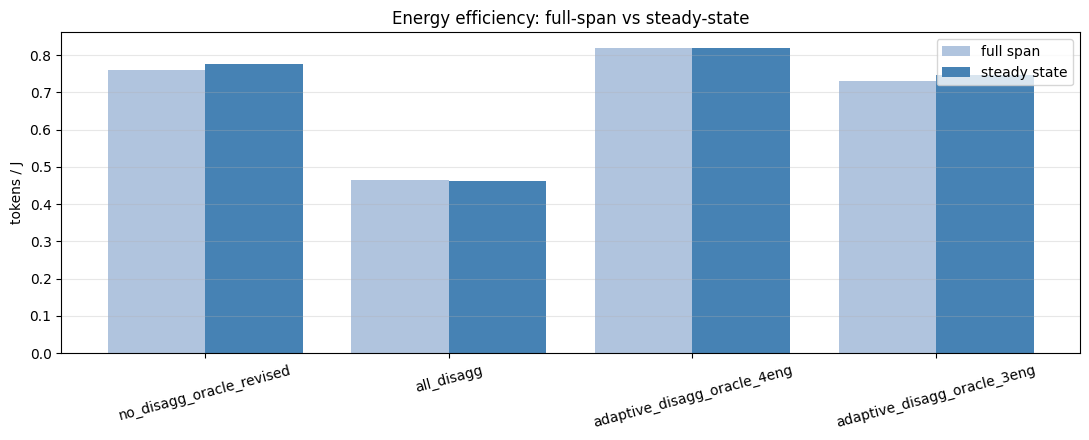

In [21]:
# ============================================================
# Steady-state energy efficiency
# ============================================================
# Two-step alignment:
#   1. Use vLLM core logs to find the period when ANY engine was actively
#      serving requests (step_end events with non-empty executed_request_ids).
#   2. Trim the head/tail (10% each) of that period to focus on steady state,
#      excluding ramp-up (Poisson load building) and wind-down (last convs
#      draining on otherwise-idle engines).
# Then re-compute mean power and tok/J inside the trimmed window.

import re
from datetime import datetime
LINE_RE = re.compile(r'^(\S+)\s+GPU\s+(\d+)\s+(\S+)\s+(\S+)')
TRIM_FRAC = 0.10

def active_window_from_core_logs(policy_dir):
    """Earliest and latest timestamp where a NON-warmup request was executing.
    Filters out cmpl-warmup-* requests so the warm-up phase is excluded."""
    t_min, t_max = None, None
    for log in sorted(policy_dir.glob('*_core_log.jsonl')):
        with open(log) as f:
            for line in f:
                try: e = json.loads(line)
                except: continue
                if e.get('event') != 'step_end': continue
                exec_ids = [r for r in (e.get('executed_request_ids') or [])
                            if 'warmup' not in r]
                if not exec_ids: continue
                ts = datetime.fromisoformat(e['timestamp']).timestamp()
                if t_min is None or ts < t_min: t_min = ts
                if t_max is None or ts > t_max: t_max = ts
    return t_min, t_max

def parse_dcgmi_window(path, t_lo, t_hi):
    per_gpu = {}
    with open(path) as f:
        for line in f:
            m = LINE_RE.match(line)
            if not m: continue
            try: ts = datetime.fromisoformat(m.group(1)).timestamp()
            except: continue
            if ts < t_lo or ts > t_hi: continue
            gid, p_s, te_s = int(m.group(2)), m.group(3), m.group(4)
            if p_s == 'N/A' or te_s == 'N/A': continue
            try: p = float(p_s); te = int(te_s)
            except: continue
            d = per_gpu.setdefault(gid, {'p_sum': 0.0, 'n': 0,
                                         'te_first': te, 'ts_first': ts,
                                         'te_last': te,  'ts_last': ts})
            d['p_sum'] += p; d['n'] += 1
            if ts < d['ts_first']: d['te_first'], d['ts_first'] = te, ts
            if ts > d['ts_last']:  d['te_last'],  d['ts_last']  = te, ts
    return per_gpu

policies_e = ['no_disagg_oracle_revised', 'all_disagg', 'adaptive_disagg_oracle_4eng', 'adaptive_disagg_oracle_3eng']
ss_rows = []
for p in policies_e:
    if p == 'adaptive_disagg_oracle_3eng':
        l_df = df3
    else:
        l_df = lat[p]
    base = ORACLE / p

    # 1. Active window from core logs
    t_act_lo, t_act_hi = active_window_from_core_logs(base)
    span_act = t_act_hi - t_act_lo

    # 2. Trim head/tail
    t_ss_lo = t_act_lo + span_act * TRIM_FRAC
    t_ss_hi = t_act_hi - span_act * TRIM_FRAC
    span_ss = t_ss_hi - t_ss_lo

    # 3. Parse dcgmi within trimmed window
    pg = parse_dcgmi_window(str(base / 'dcgmi_trace.tsv'), t_ss_lo, t_ss_hi)
    energy_J  = sum(d['te_last'] - d['te_first'] for d in pg.values()) / 1000.0
    avg_power_W = sum(d['p_sum']/d['n'] for d in pg.values())

    # 4. Tokens served within the steady-state window: count iters whose end_time is in window
    iters_in_ss = l_df[(l_df['end_time'] >= t_ss_lo) & (l_df['end_time'] <= t_ss_hi)]
    out_tok_ss = iters_in_ss['max_tokens'].sum()
    n_iters_ss = len(iters_in_ss)
    n_convs_ss = iters_in_ss['conv_id'].nunique()

    ss_rows.append({
        'policy':           p,
        'active_span_s':    round(span_act, 0),
        'ss_span_s':        round(span_ss, 0),
        'avg_power_W':      round(avg_power_W, 0),
        'energy_kJ':        round(energy_J / 1000, 1),
        'iters_in_ss':      n_iters_ss,
        'out_tok_in_ss':    out_tok_ss,
        'tok_per_J_ss':     round(out_tok_ss / energy_J, 3),
        'iters_per_kJ':     round(n_iters_ss / energy_J * 1000, 3),
    })

ss_df = pd.DataFrame(ss_rows)
print('Steady-state efficiency (active window from core logs, trimmed 10% head/tail):')
print(ss_df.to_string(index=False))
print()

# Compare to the full-span numbers from earlier
print('Full-span vs steady-state mean power:')
for full, ss in zip(energy_rows, ss_rows):
    if full['policy'] != ss['policy']: continue
    delta_p = ss['avg_power_W'] - full['avg_power_W']
    print(f'  {full["policy"]:35s}  full={full["avg_power_W"]:>4.0f}W  ss={ss["avg_power_W"]:>4.0f}W  ({delta_p:+.0f}W)')

# Bar chart: full vs steady-state tok/J
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))
xs = ss_df['policy'].values
full_eff = [r['tok_per_J']  for r in energy_rows]
ss_eff   = ss_df['tok_per_J_ss'].values
x = np.arange(len(xs))
ax.bar(x - 0.2, full_eff, 0.4, label='full span',     color='lightsteelblue')
ax.bar(x + 0.2, ss_eff,   0.4, label='steady state', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(xs, rotation=15)
ax.set_ylabel('tokens / J')
ax.set_title('Energy efficiency: full-span vs steady-state')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 5-iteration sweep

Shorter conversations (capped at 5 iters via `--max-iters 5`) — same Poisson schedule, same engines, same scheduler. Hypothesis: with shorter convs, iter-0 prefill is a bigger fraction of per-conv work, so adaptive_disagg's contention-elimination benefit should be larger relative to no_disagg.

(`all_disagg` skipped — already known to be the worst at the 9-iter setting.)

9-iter:
                           policy  span_s  conv_per_sec  tok_per_sec  queue_p50  queue_p90  TTFT_p99_ms  TBT_p50_ms  E2E_p50  E2E_p90
   no_disagg_oracle_revised [9it]  1018.0         0.250        818.0       74.1      333.1        945.0        59.7    138.3    354.3
adaptive_disagg_oracle_4eng [9it]   917.0         0.278        908.0       27.8      325.5        149.0        55.7    121.8    323.0
adaptive_disagg_oracle_3eng [9it]  1226.0         0.208        679.0      176.4      493.2        159.0        58.8    126.7    338.1

5-iter:
                           policy  span_s  conv_per_sec  tok_per_sec  queue_p50  queue_p90  TTFT_p99_ms  TBT_p50_ms  E2E_p50  E2E_p90
   no_disagg_oracle_revised [5it]   408.0         0.626        546.0        0.1        0.2        737.0        24.1     11.6     47.0
adaptive_disagg_oracle_4eng [5it]   389.0         0.656        572.0        0.1        0.2         37.0        18.3      8.1     37.0
adaptive_disagg_oracle_3eng [5it]   411.0    

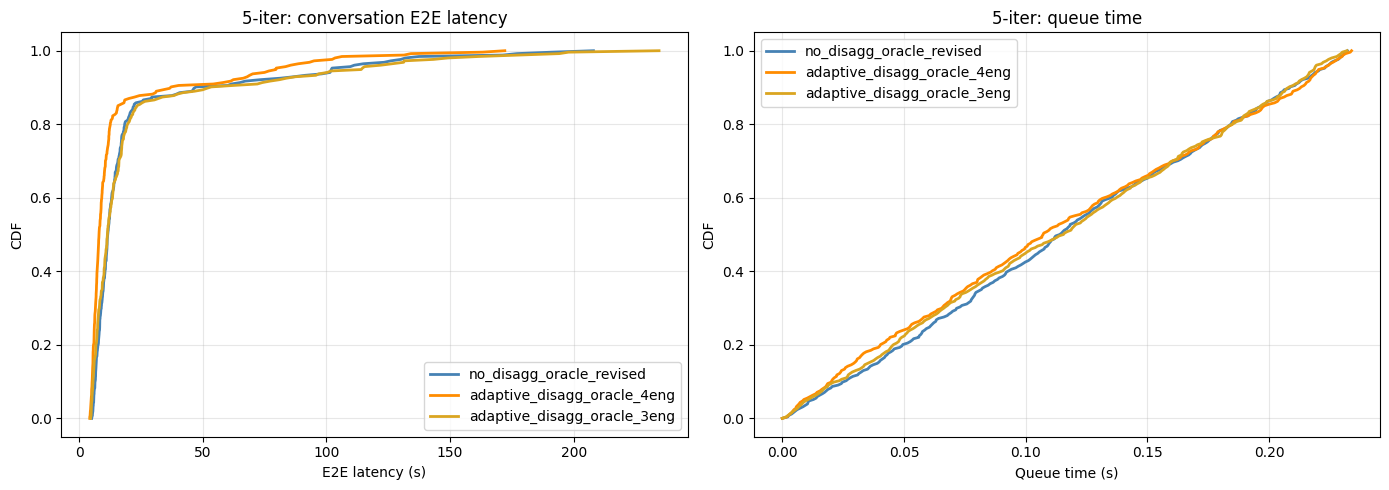

In [22]:
# ============================================================
# 5-iter results: load + compare against the 9-iter sweep
# ============================================================
ORACLE_5 = Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps1')
POLICIES_5 = ['no_disagg_oracle_revised', 'adaptive_disagg_oracle_4eng', 'adaptive_disagg_oracle_3eng']

lat5, conv5, queue5, core5 = {}, {}, {}, {}
for p in POLICIES_5:
    df = pd.read_csv(ORACLE_5 / p / 'per_step_latency.csv')
    t0 = df['start_time'].min()
    df['start_rel'] = df['start_time'] - t0
    df['end_rel']   = df['end_time']   - t0
    lat5[p] = df
    conv5[p] = conv_summary(df)
    # core logs use absolute timestamps; parse_core_logs handles that
    # Temporarily swap ORACLE so parse_core_logs reads from the right place
    _orig = ORACLE
    globals()['ORACLE'] = ORACLE_5
    try:
        core5[p] = parse_core_logs(p)
    finally:
        globals()['ORACLE'] = _orig

    # Reconstruct queueing relative to the same Poisson arrivals (seed=42)
    cs = conv5[p].sort_values('conv_id').reset_index(drop=True)
    cs['arrival'] = ARRIVALS[cs['conv_id'].values]
    cs['queue']   = (cs['first_start'] - cs['arrival']).clip(lower=0)
    queue5[p] = cs

# Side-by-side summary: 5-iter vs 9-iter
def row_for(name, l, c, q, k):
    span = l['end_rel'].max()
    n = c.shape[0]
    return {
        'policy':        name,
        'span_s':        round(span, 0),
        'conv_per_sec':  round(n / span, 3),
        'tok_per_sec':   round(l['max_tokens'].sum() / span, 0),
        'queue_p50':     round(q['queue'].median(), 1),
        'queue_p90':     round(q['queue'].quantile(0.9), 1),
        'TTFT_p99_ms':   round(k['ttft'].quantile(0.99) * 1000, 0),
        'TBT_p50_ms':    round(k[k['n_decode_steps']>1]['tbt'].median()*1000, 1),
        'E2E_p50':       round(c['e2e'].median(), 1),
        'E2E_p90':       round(c['e2e'].quantile(0.9), 1),
    }

rows_9, rows_5 = [], []
for p in POLICIES_5:
    if p == 'adaptive_disagg_oracle_3eng':
        l9, c9, q9, k9 = df3, conv3, queue3, core3
    else:
        l9, c9, q9, k9 = lat[p], conv[p], queue[p], core[p]
    rows_9.append(row_for(p + ' [9it]', l9, c9, q9, k9))
    rows_5.append(row_for(p + ' [5it]', lat5[p], conv5[p], queue5[p], core5[p]))

print('9-iter:')
print(pd.DataFrame(rows_9).to_string(index=False))
print()
print('5-iter:')
print(pd.DataFrame(rows_5).to_string(index=False))

# Throughput delta vs no_disagg, side-by-side
print()
print('Throughput advantage of adaptive_4eng vs no_disagg:')
nd_9 = next(r for r in rows_9 if 'no_disagg' in r['policy'])
a4_9 = next(r for r in rows_9 if '4eng' in r['policy'])
nd_5 = next(r for r in rows_5 if 'no_disagg' in r['policy'])
a4_5 = next(r for r in rows_5 if '4eng' in r['policy'])
print(f'  9-iter: {a4_9["conv_per_sec"]} vs {nd_9["conv_per_sec"]}  '
      f'(adaptive +{(a4_9["conv_per_sec"] - nd_9["conv_per_sec"])/nd_9["conv_per_sec"]:.0%})')
print(f'  5-iter: {a4_5["conv_per_sec"]} vs {nd_5["conv_per_sec"]}  '
      f'(adaptive +{(a4_5["conv_per_sec"] - nd_5["conv_per_sec"])/nd_5["conv_per_sec"]:.0%})')

print()
print('Engine-count effect (4eng vs 3eng adaptive):')
a3_9 = next(r for r in rows_9 if '3eng' in r['policy'])
a3_5 = next(r for r in rows_5 if '3eng' in r['policy'])
print(f'  9-iter: 4eng = {a4_9["conv_per_sec"]}, 3eng = {a3_9["conv_per_sec"]}  '
      f'(3eng = {a3_9["conv_per_sec"]/a4_9["conv_per_sec"]:.0%} of 4eng — naive 3/4 = 75%)')
print(f'  5-iter: 4eng = {a4_5["conv_per_sec"]}, 3eng = {a3_5["conv_per_sec"]}  '
      f'(3eng = {a3_5["conv_per_sec"]/a4_5["conv_per_sec"]:.0%} of 4eng)')

# E2E + queue CDFs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_5 = {'no_disagg_oracle_revised': 'steelblue',
            'adaptive_disagg_oracle_4eng': 'darkorange',
            'adaptive_disagg_oracle_3eng': 'goldenrod'}
for p in POLICIES_5:
    e = np.sort(conv5[p]['e2e'].values)
    axes[0].plot(e, np.linspace(0,1,len(e)), label=p, color=colors_5[p], linewidth=2)
    qq = np.sort(queue5[p]['queue'].values)
    axes[1].plot(qq, np.linspace(0,1,len(qq)), label=p, color=colors_5[p], linewidth=2)
axes[0].set_xlabel('E2E latency (s)'); axes[0].set_ylabel('CDF')
axes[0].set_title('5-iter: conversation E2E latency'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Queue time (s)'); axes[1].set_ylabel('CDF')
axes[1].set_title('5-iter: queue time'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


5-iter energy efficiency:
                     policy  span_s  avg_W_full  avg_W_ss  energy_kJ_full  tok_per_J_full  tok_per_J_ss
   no_disagg_oracle_revised   408.0       854.0     919.0           347.2           0.641         0.658
adaptive_disagg_oracle_4eng   389.0       813.0     877.0           315.6           0.705         0.723
adaptive_disagg_oracle_3eng   411.0       783.0     840.0           320.3           0.694         0.712

Comparison vs 9-iter (full-span tok/J):
  no_disagg_oracle_revised             9-iter: 0.761  →  5-iter: 0.641  (-16%)
  adaptive_disagg_oracle_4eng          9-iter: 0.819  →  5-iter: 0.705  (-14%)
  adaptive_disagg_oracle_3eng          9-iter: 0.731  →  5-iter: 0.694  (-5%)


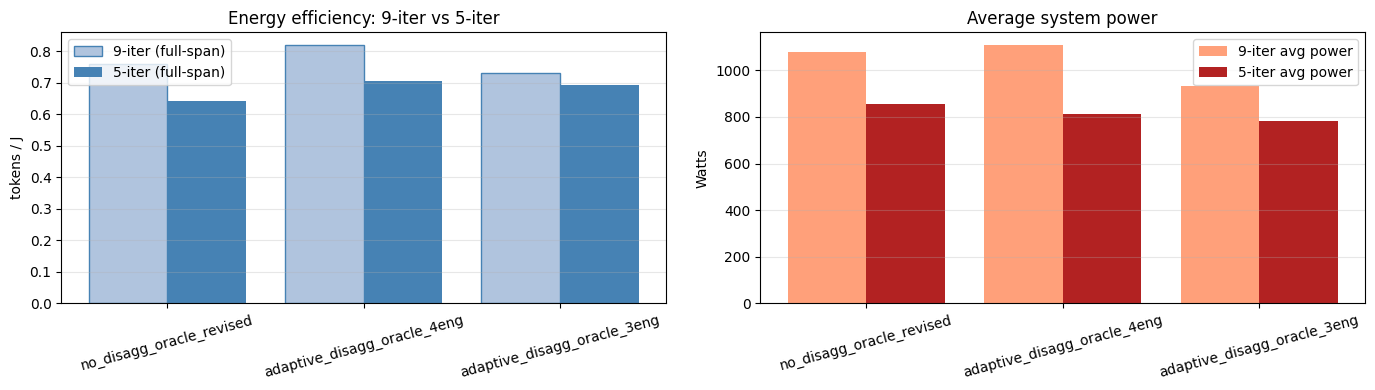

In [23]:
# ============================================================
# Energy efficiency: 5-iter sweep, full-span and steady-state
# ============================================================
import re
from datetime import datetime

LINE_RE = re.compile(r'^(\S+)\s+GPU\s+(\d+)\s+(\S+)\s+(\S+)')
TRIM_FRAC = 0.10

def active_window_no_warmup(policy_dir):
    t_min, t_max = None, None
    for log in sorted(policy_dir.glob('*_core_log.jsonl')):
        with open(log) as f:
            for line in f:
                try: e = json.loads(line)
                except: continue
                if e.get('event') != 'step_end': continue
                exec_ids = [r for r in (e.get('executed_request_ids') or [])
                            if 'warmup' not in r]
                if not exec_ids: continue
                ts = datetime.fromisoformat(e['timestamp']).timestamp()
                if t_min is None or ts < t_min: t_min = ts
                if t_max is None or ts > t_max: t_max = ts
    return t_min, t_max

def parse_dcgmi(path, t_lo, t_hi):
    per_gpu = {}
    with open(path) as f:
        for line in f:
            m = LINE_RE.match(line)
            if not m: continue
            try: ts = datetime.fromisoformat(m.group(1)).timestamp()
            except: continue
            if ts < t_lo or ts > t_hi: continue
            gid, p_s, te_s = int(m.group(2)), m.group(3), m.group(4)
            if p_s == 'N/A' or te_s == 'N/A': continue
            try: p = float(p_s); te = int(te_s)
            except: continue
            d = per_gpu.setdefault(gid, {'p_sum': 0.0, 'n': 0,
                                         'te_first': te, 'ts_first': ts,
                                         'te_last': te,  'ts_last': ts})
            d['p_sum'] += p; d['n'] += 1
            if ts < d['ts_first']: d['te_first'], d['ts_first'] = te, ts
            if ts > d['ts_last']:  d['te_last'],  d['ts_last']  = te, ts
    return per_gpu


energy_5_rows = []
for p in POLICIES_5:
    base = ORACLE_5 / p
    l_df = lat5[p]
    t_full_lo, t_full_hi = l_df['start_time'].min(), l_df['end_time'].max()
    t_act_lo, t_act_hi   = active_window_no_warmup(base)
    span_act = t_act_hi - t_act_lo
    t_ss_lo  = t_act_lo + span_act * TRIM_FRAC
    t_ss_hi  = t_act_hi - span_act * TRIM_FRAC

    pg_full = parse_dcgmi(str(base / 'dcgmi_trace.tsv'), t_full_lo, t_full_hi)
    pg_ss   = parse_dcgmi(str(base / 'dcgmi_trace.tsv'), t_ss_lo,  t_ss_hi)

    e_full_J = sum(d['te_last'] - d['te_first'] for d in pg_full.values()) / 1000
    e_ss_J   = sum(d['te_last'] - d['te_first'] for d in pg_ss.values())   / 1000
    avg_full = sum(d['p_sum']/d['n'] for d in pg_full.values())
    avg_ss   = sum(d['p_sum']/d['n'] for d in pg_ss.values())

    iters_in_ss = l_df[(l_df['end_time'] >= t_ss_lo) & (l_df['end_time'] <= t_ss_hi)]
    out_tok_full = l_df['max_tokens'].sum()
    out_tok_ss   = iters_in_ss['max_tokens'].sum()

    energy_5_rows.append({
        'policy':           p,
        'span_s':           round(t_full_hi - t_full_lo, 0),
        'avg_W_full':       round(avg_full, 0),
        'avg_W_ss':         round(avg_ss, 0),
        'energy_kJ_full':   round(e_full_J / 1000, 1),
        'tok_per_J_full':   round(out_tok_full / e_full_J, 3),
        'tok_per_J_ss':     round(out_tok_ss / e_ss_J, 3),
    })

energy_5_df = pd.DataFrame(energy_5_rows)
print('5-iter energy efficiency:')
print(energy_5_df.to_string(index=False))
print()

# Side-by-side with 9-iter
print('Comparison vs 9-iter (full-span tok/J):')
for p in POLICIES_5:
    e9 = next(r for r in energy_rows if r['policy'] == p)
    e5 = next(r for r in energy_5_rows if r['policy'] == p)
    print(f'  {p:35s}  9-iter: {e9["tok_per_J"]:.3f}  →  5-iter: {e5["tok_per_J_full"]:.3f}  '
          f'({(e5["tok_per_J_full"]-e9["tok_per_J"])/e9["tok_per_J"]:+.0%})')

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
xs = energy_5_df['policy'].values
colors_e5 = {'no_disagg_oracle_revised': 'steelblue',
             'adaptive_disagg_oracle_4eng': 'darkorange',
             'adaptive_disagg_oracle_3eng': 'goldenrod'}
cs = [colors_e5[x] for x in xs]
xn = np.arange(len(xs))
e9_tok_per_J = [next(r for r in energy_rows if r['policy'] == p)['tok_per_J'] for p in xs]
e5_tok_per_J = energy_5_df['tok_per_J_full'].values
axes[0].bar(xn - 0.2, e9_tok_per_J, 0.4, label='9-iter (full-span)', color='lightsteelblue', edgecolor='steelblue')
axes[0].bar(xn + 0.2, e5_tok_per_J, 0.4, label='5-iter (full-span)', color='steelblue')
axes[0].set_xticks(xn); axes[0].set_xticklabels(xs, rotation=15)
axes[0].set_ylabel('tokens / J'); axes[0].set_title('Energy efficiency: 9-iter vs 5-iter')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

e9_avg_W = [next(r for r in energy_rows if r['policy'] == p)['avg_power_W'] for p in xs]
e5_avg_W = energy_5_df['avg_W_full'].values
axes[1].bar(xn - 0.2, e9_avg_W, 0.4, label='9-iter avg power', color='lightsalmon')
axes[1].bar(xn + 0.2, e5_avg_W, 0.4, label='5-iter avg power', color='firebrick')
axes[1].set_xticks(xn); axes[1].set_xticklabels(xs, rotation=15)
axes[1].set_ylabel('Watts'); axes[1].set_title('Average system power')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## RPS sweep (5-iter convs)

Same 5-iter cap, increasing the Poisson arrival rate to push the system from
arrival-bound (RPS=1) toward capacity-bound. RPS=1.5 and RPS=2 added to test
whether contention-elimination becomes more visible under load.

**Note:** since RPS is fixed in the scheduler at module load time, each RPS run
used a different code build — the Poisson arrival sequence DIFFERS across runs
(different `random.expovariate(rps)` draws), so direct queue-time comparison
across different RPS values is approximate.

In [24]:
# ============================================================
# RPS sweep at 5 iters: aggregate metrics
# ============================================================
import re
from datetime import datetime

LINE_RE = re.compile(r'^(\S+)\s+GPU\s+(\d+)\s+(\S+)\s+(\S+)')

ORACLE_5_RPS = {
    1.0: Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps1'),
    1.5: Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps1-5'),
    2.0: Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps2'),
}

POLICIES_RPS = ['no_disagg_oracle_revised', 'adaptive_disagg_oracle_4eng', 'adaptive_disagg_oracle_3eng']

# Load every (rps, policy) pair: latency CSV + core logs + arrival reconstruction
def poisson_at_rps(rps, n=NUM_CONVS, seed=42):
    r = random.Random(seed)
    arr = [0.0]
    for _ in range(n - 1):
        arr.append(arr[-1] + r.expovariate(rps))
    return np.array(arr)

def parse_dcgmi(path, t_lo, t_hi):
    per_gpu = {}
    with open(path) as f:
        for line in f:
            m = LINE_RE.match(line)
            if not m: continue
            try: ts = datetime.fromisoformat(m.group(1)).timestamp()
            except: continue
            if ts < t_lo or ts > t_hi: continue
            gid, p_s, te_s = int(m.group(2)), m.group(3), m.group(4)
            if p_s == 'N/A' or te_s == 'N/A': continue
            try: p = float(p_s); te = int(te_s)
            except: continue
            d = per_gpu.setdefault(gid, {'p_sum': 0.0, 'n': 0, 'te_first': te, 'te_last': te,
                                         'ts_first': ts, 'ts_last': ts})
            d['p_sum'] += p; d['n'] += 1
            if ts < d['ts_first']: d['te_first'], d['ts_first'] = te, ts
            if ts > d['ts_last']:  d['te_last'],  d['ts_last']  = te, ts
    return per_gpu

rps_rows = []
for rps, base in ORACLE_5_RPS.items():
    arrivals = poisson_at_rps(rps)
    for p in POLICIES_RPS:
        l_df = pd.read_csv(base / p / 'per_step_latency.csv')
        t_min = l_df['start_time'].min()
        l_df['start_rel'] = l_df['start_time'] - t_min
        l_df['end_rel']   = l_df['end_time']   - t_min

        # Per-conv summary
        cs = l_df.groupby('conv_id').agg(first_start=('start_rel','min'),
                                          last_end=('end_rel','max'),
                                          n_iters=('step_id','count'),
                                          out=('max_tokens','sum')).reset_index()
        cs['e2e'] = cs['last_end'] - cs['first_start']
        cs = cs.sort_values('conv_id').reset_index(drop=True)
        cs['arrival'] = arrivals[cs['conv_id'].values]
        cs['queue']   = (cs['first_start'] - cs['arrival']).clip(lower=0)

        # Core logs (TTFT, TBT)
        old = globals().get('ORACLE')
        globals()['ORACLE'] = base
        try:
            k_df = parse_core_logs(p)
        finally:
            globals()['ORACLE'] = old

        # dcgmi for energy
        t_full_lo, t_full_hi = l_df['start_time'].min(), l_df['end_time'].max()
        pg = parse_dcgmi(str(base / p / 'dcgmi_trace.tsv'), t_full_lo, t_full_hi)
        e_J = sum(d['te_last'] - d['te_first'] for d in pg.values()) / 1000
        avg_W = sum(d['p_sum']/d['n'] for d in pg.values())

        span = l_df['end_rel'].max()
        n_convs = cs.shape[0]
        out_tok = l_df['max_tokens'].sum()
        rps_rows.append({
            'rps':           rps,
            'policy':        p,
            'span_s':        round(span, 0),
            'conv_per_sec':  round(n_convs / span, 3),
            'tok_per_sec':   round(out_tok / span, 0),
            'queue_p50':     round(cs['queue'].median(), 1),
            'queue_p90':     round(cs['queue'].quantile(0.9), 1),
            'TTFT_p99_ms':   round(k_df['ttft'].quantile(0.99) * 1000, 0),
            'TBT_p50_ms':    round(k_df[k_df['n_decode_steps']>1]['tbt'].median()*1000, 1),
            'E2E_p50':       round(cs['e2e'].median(), 1),
            'E2E_p90':       round(cs['e2e'].quantile(0.9), 1),
            'avg_W':         round(avg_W, 0),
            'tok_per_J':     round(out_tok / e_J, 3),
        })

rps_df = pd.DataFrame(rps_rows)
print(rps_df.to_string(index=False))


 rps                      policy  span_s  conv_per_sec  tok_per_sec  queue_p50  queue_p90  TTFT_p99_ms  TBT_p50_ms  E2E_p50  E2E_p90  avg_W  tok_per_J
 1.0    no_disagg_oracle_revised   408.0         0.626        546.0        0.1        0.2        737.0        24.1     11.6     47.0  854.0      0.641
 1.0 adaptive_disagg_oracle_4eng   389.0         0.656        572.0        0.1        0.2         37.0        18.3      8.1     37.0  813.0      0.705
 1.0 adaptive_disagg_oracle_3eng   411.0         0.621        542.0        0.1        0.2          0.0        26.2     11.4     52.7  783.0      0.694
 1.5    no_disagg_oracle_revised   356.0         0.717        625.0        0.1        0.2        900.0        36.8     18.6     86.2  938.0      0.670
 1.5 adaptive_disagg_oracle_4eng   330.0         0.772        673.0        0.1        0.2         48.0        24.2     11.2     52.5  889.0      0.760
 1.5 adaptive_disagg_oracle_3eng   370.0         0.689        601.0        0.1        1.2     

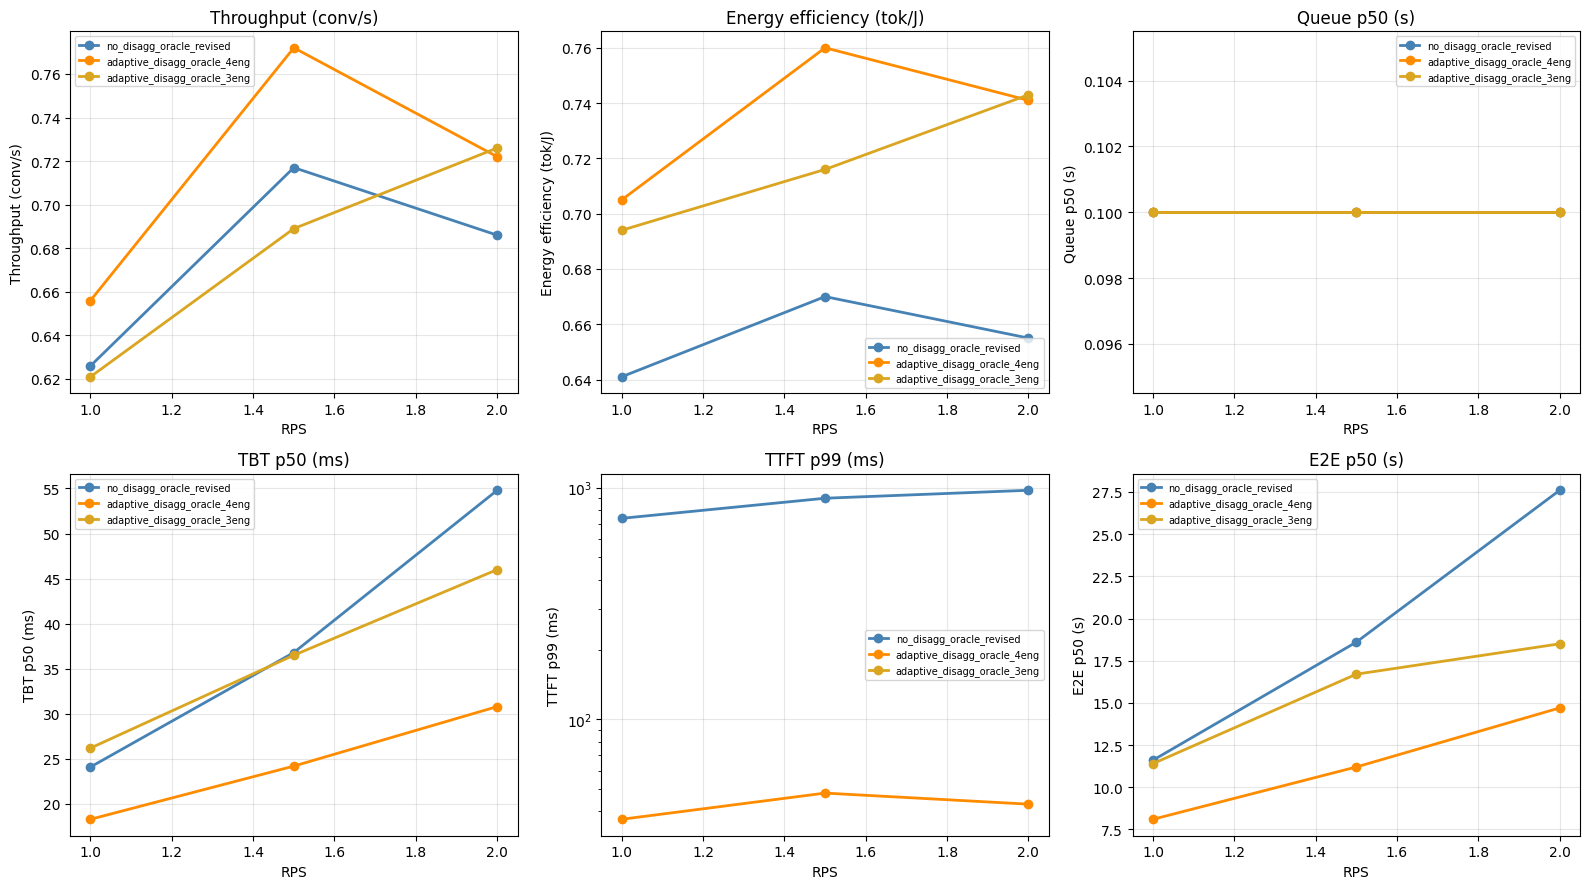

Throughput advantage of adaptive_4eng vs no_disagg per RPS:
  RPS=1.0:  no_disagg=0.626  adaptive_4eng=0.656 (+5%)  adaptive_3eng=0.621 (-1%)
  RPS=1.5:  no_disagg=0.717  adaptive_4eng=0.772 (+8%)  adaptive_3eng=0.689 (-4%)
  RPS=2.0:  no_disagg=0.686  adaptive_4eng=0.722 (+5%)  adaptive_3eng=0.726 (+6%)

Effective ceiling per policy (max conv/s across RPS):
  no_disagg_oracle_revised             ceiling=0.717 conv/s @ RPS=1.5
  adaptive_disagg_oracle_4eng          ceiling=0.772 conv/s @ RPS=1.5
  adaptive_disagg_oracle_3eng          ceiling=0.726 conv/s @ RPS=2.0


In [25]:
# ── Plots: how do metrics evolve as RPS rises? ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = [
    ('conv_per_sec', 'Throughput (conv/s)', False),
    ('tok_per_J',    'Energy efficiency (tok/J)', False),
    ('queue_p50',    'Queue p50 (s)', False),
    ('TBT_p50_ms',   'TBT p50 (ms)', False),
    ('TTFT_p99_ms',  'TTFT p99 (ms)', True),  # log scale
    ('E2E_p50',      'E2E p50 (s)', False),
]
colors_rps = {'no_disagg_oracle_revised': 'steelblue',
              'adaptive_disagg_oracle_4eng': 'darkorange',
              'adaptive_disagg_oracle_3eng': 'goldenrod'}
for ax, (col, label, log) in zip(axes.flatten(), metrics):
    for p in POLICIES_RPS:
        sub = rps_df[rps_df['policy'] == p].sort_values('rps')
        ax.plot(sub['rps'], sub[col], 'o-', label=p, color=colors_rps[p], linewidth=2)
    ax.set_xlabel('RPS'); ax.set_ylabel(label); ax.set_title(label)
    if log: ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Highlight: throughput delta vs no_disagg at each RPS
print('Throughput advantage of adaptive_4eng vs no_disagg per RPS:')
for rps in sorted(rps_df['rps'].unique()):
    nd = rps_df[(rps_df['rps']==rps) & (rps_df['policy']=='no_disagg_oracle_revised')]['conv_per_sec'].iloc[0]
    a4 = rps_df[(rps_df['rps']==rps) & (rps_df['policy']=='adaptive_disagg_oracle_4eng')]['conv_per_sec'].iloc[0]
    a3 = rps_df[(rps_df['rps']==rps) & (rps_df['policy']=='adaptive_disagg_oracle_3eng')]['conv_per_sec'].iloc[0]
    print(f'  RPS={rps}:  no_disagg={nd}  adaptive_4eng={a4} (+{(a4-nd)/nd:.0%})  '
          f'adaptive_3eng={a3} ({(a3-nd)/nd:+.0%})')

print()
print('Effective ceiling per policy (max conv/s across RPS):')
for p in POLICIES_RPS:
    sub = rps_df[rps_df['policy']==p]
    best = sub.loc[sub['conv_per_sec'].idxmax()]
    print(f'  {p:35s}  ceiling={best["conv_per_sec"]} conv/s @ RPS={best["rps"]}')


In [26]:
# ============================================================
# Re-compute TTFT correctly using step_start ↔ step_end pairs
# ============================================================
# Previous parser used step_end timestamps for BOTH the arrival point and the
# first-token point. When a request entered and produced its first token in the
# same step, that gave TTFT = 0 — wrong. The true TTFT is from the step_START
# of the first step where the request was executed, to the step_END of the first
# step where it produced a token. That's >= one step duration (~20ms).

import re
from datetime import datetime
from collections import defaultdict
RID2 = re.compile(r'cmpl-(\d+)-(\d+)-0$')

def parse_core_logs_v2(policy_dir):
    """Per-request events as (step_start, step_end, in_executed, in_finished, ct, engine)."""
    by_req_eng = defaultdict(lambda: defaultdict(list))
    for log in sorted(Path(policy_dir).glob('*_core_log.jsonl')):
        eng = log.name.replace('_vllm_core_log.jsonl', '')
        prev_start = None
        with open(log) as f:
            for line in f:
                try: e = json.loads(line)
                except: continue
                if e.get('event') == 'step_start':
                    prev_start = datetime.fromisoformat(e['timestamp']).timestamp()
                elif e.get('event') == 'step_end':
                    ts_end = datetime.fromisoformat(e['timestamp']).timestamp()
                    ts_start = prev_start if prev_start is not None else ts_end
                    exec_set = set(e.get('executed_request_ids', []))
                    fin_set  = set(e.get('finished_request_ids', []))
                    fin_ct   = dict(zip(e.get('finished_request_ids', []),
                                        e.get('num_cached_tokens', [])))
                    for rid in exec_set | fin_set:
                        if 'warmup' in rid: continue
                        m = RID2.match(rid)
                        if not m: continue
                        k = (int(m.group(1)), int(m.group(2)))
                        by_req_eng[k][eng].append(
                            (ts_start, ts_end, rid in exec_set, rid in fin_set, fin_ct.get(rid, 0))
                        )
    rows = []
    for (cid, itid), engs in by_req_eng.items():
        all_ev = [(s, e, ie, ifn, ct, eng) for eng, lst in engs.items() for s, e, ie, ifn, ct in lst]
        if not all_ev: continue
        t_arrived_start = min(s for s, _, ie, _, _, _ in all_ev if ie)
        fin_ends = sorted(e for _, e, _, ifn, _, _ in all_ev if ifn)
        if not fin_ends: continue
        t_first_end = fin_ends[0]
        t_last_end  = fin_ends[-1]
        cached = next((ct for _, _, _, ifn, ct, _ in all_ev if ifn and ct), 0)
        # TBT: count finished step_ends on dominant engine, use step_end timestamps
        eng_finished = {eng: sorted(e for _, e, _, ifn, _ in lst if ifn)
                        for eng, lst in engs.items()}
        decode_eng = max(eng_finished, key=lambda x: len(eng_finished[x]))
        d_ts = eng_finished[decode_eng]
        n_dec = len(d_ts)
        decode_dur = (d_ts[-1] - d_ts[0]) if n_dec > 1 else 0.0
        tbt = (decode_dur / (n_dec - 1)) if n_dec > 1 else float('nan')
        rows.append({
            'conv_id': cid, 'iter_id': itid, 'engine': decode_eng,
            't_arrived_start': t_arrived_start,
            't_first_end': t_first_end,
            't_last_end': t_last_end,
            'ttft': t_first_end - t_arrived_start,   # ← corrected
            'n_decode_steps': n_dec, 'tbt': tbt,
            'cached_tokens': cached,
        })
    return pd.DataFrame(rows)

# Re-parse RPS-sweep policies with corrected TTFT
ORACLE_5_RPS = {
    1.0: Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps1'),
    1.5: Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps1-5'),
    2.0: Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/oracle_5iter_rps2'),
}
print('Corrected TTFT distributions:')
print(f'{"rps":>4} {"policy":40s} {"TTFT_p50_ms":>11} {"TTFT_p90_ms":>11} {"TTFT_p99_ms":>11} {"max_ms":>8}')
for rps, base in ORACLE_5_RPS.items():
    for p in POLICIES_RPS:
        df = parse_core_logs_v2(base / p)
        df_iter0 = df[df['iter_id'] == 0]
        ttft_ms = df['ttft'] * 1000
        print(f'{rps:>4} {p:40s} {ttft_ms.median():>11.1f} {ttft_ms.quantile(0.9):>11.1f} '
              f'{ttft_ms.quantile(0.99):>11.1f} {ttft_ms.max():>8.0f}')


Corrected TTFT distributions:
 rps policy                                   TTFT_p50_ms TTFT_p90_ms TTFT_p99_ms   max_ms


 1.0 no_disagg_oracle_revised                        40.2       688.9       844.6      975


 1.0 adaptive_disagg_oracle_4eng                     25.4        40.4       195.4      740


 1.0 adaptive_disagg_oracle_3eng                     39.7        57.8       116.2      739


 1.5 no_disagg_oracle_revised                        70.3       763.9      1044.7     1218


 1.5 adaptive_disagg_oracle_4eng                     38.3        55.6       224.2      736


 1.5 adaptive_disagg_oracle_3eng                     54.5        83.7        98.9      743


 2.0 no_disagg_oracle_revised                       100.7       847.4      1135.3     1313


 2.0 adaptive_disagg_oracle_4eng                     42.7        72.1       220.7      739


 2.0 adaptive_disagg_oracle_3eng                     67.3        86.0       144.0      743


Distribution of out_token_size by iter:
      min   max        mean    p50    p90      p99
iter                                              
0      64   318  117.745098  106.0  160.6   286.22
1      34    69   41.200000   40.0   45.6    60.00
2      31   159   51.505882   49.0   65.0   103.44
3      29  9502  208.623529   54.0  166.8  4549.50
4      31  7985  452.992157  131.0  647.2  5237.18


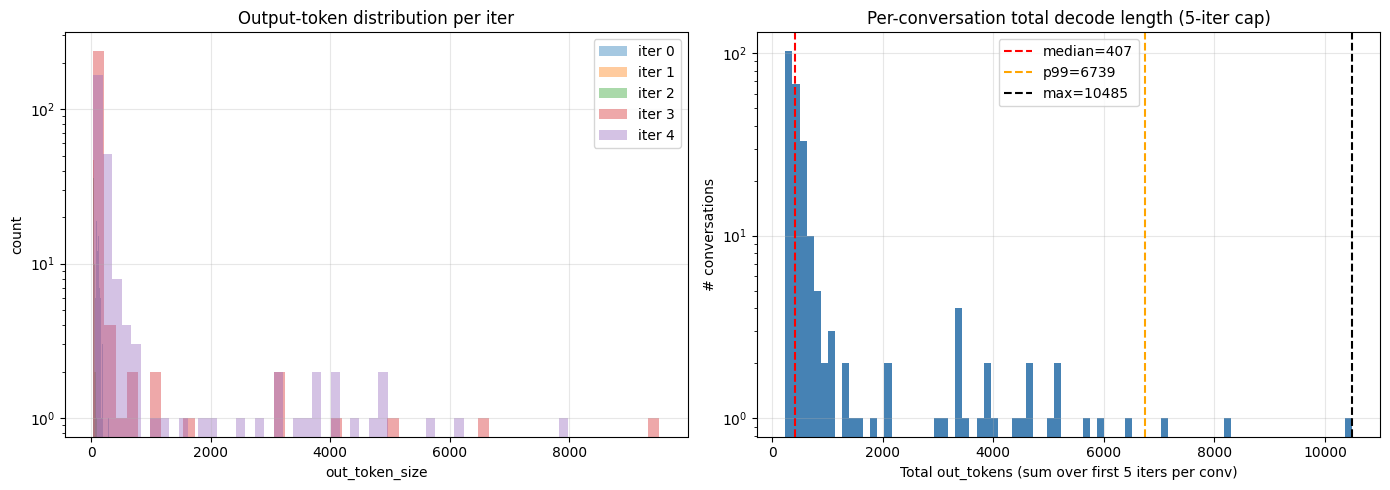


Total decode tokens (5-iter cap, all 255 convs): 222,377
  Top 1% of convs (2 convs) account for: 8.4%
  Top 10% of convs account for: 53.1%
  Median conv contributes: 0.18%
  Max conv contributes:    4.71%


In [27]:
# ============================================================
# Output-length distribution per iter (from PROMPT_DATA)
# ============================================================
# Hypothesis: the experiment span at saturation is dominated by a few stragglers
# with huge decode lengths. Plot the per-iter distribution of out_token_size
# for the first 5 iters of every conversation in the trace.

import sys
if '/data/projects/AgentScaling/adaptive_agentic_serving/src' not in sys.path:
    sys.path.insert(0, '/data/projects/AgentScaling/adaptive_agentic_serving/src')
import importlib
import input_loader as cfg
importlib.reload(cfg)

iters_data = []
for cid in range(cfg.CONV_COUNT):
    for it in range(min(5, cfg.ITER_COUNT[cid])):
        if (cid, it) not in cfg.PROMPT_DATA: continue
        iters_data.append({'conv_id': cid, 'iter': it,
                           'in_size': cfg.PROMPT_DATA[(cid, it)]['in_token_size'],
                           'out_size': cfg.PROMPT_DATA[(cid, it)]['out_token_size']})
itr_df = pd.DataFrame(iters_data)
print(f'Distribution of out_token_size by iter:')
stat = itr_df.groupby('iter')['out_size'].agg(['min','median','mean','quantile','max']).rename(columns={'quantile': 'p25'})
# Compute multiple percentiles cleanly
quantiles = itr_df.groupby('iter')['out_size'].quantile([0.5, 0.9, 0.99]).unstack(level=-1)
quantiles.columns = ['p50', 'p90', 'p99']
mxmn = itr_df.groupby('iter')['out_size'].agg(['min', 'max', 'mean'])
combined = pd.concat([mxmn, quantiles], axis=1)
print(combined.to_string())

# Plot per-iter distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for iter_id in range(5):
    sub = itr_df[itr_df['iter'] == iter_id]
    ax.hist(sub['out_size'], bins=50, alpha=0.4, label=f'iter {iter_id}')
ax.set_xlabel('out_token_size'); ax.set_ylabel('count')
ax.set_title('Output-token distribution per iter')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)

# Total per-conv across first 5 iters (= what 5-iter experiments actually decode)
ax = axes[1]
total = itr_df.groupby('conv_id')['out_size'].sum()
ax.hist(total, bins=80, color='steelblue')
ax.set_xlabel('Total out_tokens (sum over first 5 iters per conv)')
ax.set_ylabel('# conversations')
ax.set_title('Per-conversation total decode length (5-iter cap)')
ax.set_yscale('log'); ax.grid(alpha=0.3)
ax.axvline(total.median(), color='red', linestyle='--', label=f'median={total.median():.0f}')
ax.axvline(total.quantile(0.99), color='orange', linestyle='--', label=f'p99={total.quantile(0.99):.0f}')
ax.axvline(total.max(), color='black', linestyle='--', label=f'max={total.max():.0f}')
ax.legend()

plt.tight_layout(); plt.show()

# How concentrated is the decode work?
sorted_total = sorted(total.values, reverse=True)
total_sum = sum(sorted_total)
print()
print(f'Total decode tokens (5-iter cap, all 255 convs): {total_sum:,}')
print(f'  Top 1% of convs ({len(sorted_total)//100} convs) account for: '
      f'{sum(sorted_total[:max(1, len(sorted_total)//100)])/total_sum:.1%}')
print(f'  Top 10% of convs account for: '
      f'{sum(sorted_total[:len(sorted_total)//10])/total_sum:.1%}')
print(f'  Median conv contributes: {total.median()/total_sum:.2%}')
print(f'  Max conv contributes:    {total.max()/total_sum:.2%}')
